# <u>Supervised Neural Networks for Regression and Classification</u>

### Prerequisites:
* <a href="../Supervised ML Basis.ipynb">Check out the notebook on Supervised ML Basics</a>

## Topics

* [1. Perceptron](#perceptron)
* [2. Single Hidden Layer Neural Networks (Multi-Layer Perceptron)](#single)
* [3.1 Single hidden layer networks with one output neuron](#one)
* [3.2 Single hidden layer networks with multiple output neurons](#multiple)
* [3.3 Multi-layer feedforward networks](#feedforward)
* [4. Training Neural Networks](#neural)
* [5. Loss Functions](#loss)
* [6. Gradient Descent](#gradient)
* [7. Stochastic Gradient Descent (SGD)](#SGD)
* [8. Momentum](#momentum)
* [9. Backpropagation](#back)
* [10. Example 1](#example1)
* [11. Example 2](#example2)
* [12. Example 3](#example3)
* [13. Example 4](#example4)
* [14. Example 5](#example5)
* [15. Example 6](#example6)
* [16. Matrix dimensions of multiple hidden-layer neural networks](#dim)
* [17. Example 7](#example7)
* [18.1 Neural Networks for Regression library](#library1)
* [18.2 Neural Networks for Classification library](#library2)


In [92]:
import numpy as np  # for random numbers and numpy arrays
import pandas as pd # for dataframes
import matplotlib.pyplot as plt # for 2D Plots


# Neural network classes
import sklearn
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
#print(sklearn.__version__)

# PyTorch
import torch # main PyTorch library for i.e. multi-dimensional arrays
import torch.nn.functional as F # PyTorch's functional API
import torch.nn as nn # imports PyTorch's neural network module which contains layers and model-building components 
                      # i.e. nn.Linear(10,5) meaning 10 input neurons and 5 output neurons and 
                      # i.e. model = nn.Sequential(
                      #                  nn.Linear(10, 5),  # input -> hidden
                      #                  nn.ReLU(),         # or nn.Sigmoid()
                      #                  nn.Linear(5, 1)    # hidden -> output
                      #      )
import torch.optim as optim # Imports optimization algorithms used during training and ppdates model weights to minimize loss
                            # i.e. optim.SGD(model.parameters(), lr=0.01) or optim.Adam(model.parameters(), lr=0.001)
#print(torch.__version__)

# TensorFlow / Keras (Deep learning framework)
import tensorflow as tf # Imports the main TensorFlow library and provides tensors, automatic differentiation, distributed computing 
                        # and deep learning tools (i.e. x = tf.constant([1, 2, 3]))
from tensorflow import keras # Imports Keras, TensorFlow's high-level deep learning API. It makes building neural networks easier (i.e. model = keras.Sequential())
from tensorflow.keras import layers # Imports common neural network layers used when constructing models (i.e. layers.Dense(64, activation='relu'))
#print(tf.__version__)

from sklearn.datasets import load_iris # Iris dataset
from sklearn.preprocessing import StandardScaler # Standardize features
from sklearn.model_selection import train_test_split # split dataset in train and testset
from sklearn.metrics import accuracy_score # accuracy score

print("Setup complete")

Setup complete


<a class="anchor" id="perceptron"></a>

# 1. Preceptron

**The Perceptron is the basic computational unit for neural networks with only one single artificial neuron**

<p align="center">
<img src="pics/1.png" width="400"/>
</p>

- Input layer: $x_1,\ldots,x_p$ are the input features
- $w_1,\ldots,w_p$ are the weights with bias term $b$
- One output neuron: $f(x)=\tau(w_1x_1 + \ldots + w_px_p + b)=\tau(w^\top x + b)$ with acitivation function $\tau$ 

### Choices for activation functions:
- Identity function (Linear Regression)
$$
f(x)=\tau (w^\top x) = w^\top x 
$$

- Logistic function (Logistic Regression)
$$
f(x) = \tau(w^\top x) = \frac{1}{1+ \exp(-w^\top x)}
$$

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

- A $p$-dimensional input vector $x$ is presented by $p$ nodes in the input layer
- Consider a perceptron with 3-dimensional input vector $x$
$$
f(x)=\tau(w_1x_1+w_2x_2 + w_3x_3 + b)
$$

<p align="center">
<img src="pics/2.png" width="150"/>
</p>


</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

- Weights $w$ are connected to edges from the input layer
- Since this is a perceptron there are as many weights as the dimension of the input vector
- The bias term $b$ is often not visualized as separate node

<p align="center">
<img src="pics/3.png" width="350"/>
</p>


</div>
</div>

---

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

- To visualize the bias $b$ as a node  add a constant feature to the input vector $\tilde{x}=(1,x_1,\ldots,x_p)^\top$
- Add the bias $b$ to the weights vector $\tilde{w}=(b,w_1,\ldots,w_p)$

<p align="center">
<img src="pics/4.png" width="250"/>
</p>


</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

- Computation $\tau(w_1x_1+w_2x_2+w_3x_3 + b)$ with activation function $\tau$ is represented by the neuron in the output layer

<p align="center">
<img src="pics/5.png" width="350"/>
</p>


</div>
</div>

### A neuron performs a 2-step computation:

**1. Affine Transformation: Weighted sum of inputs plus the bias**
- The neuron first perfroms the affine transformation

<p align="center">
<img src="pics/6.png" width="350"/>
</p>

**2. Non-linear Activation: A non-linear transformation applied to the weighted sum**
- The neuron then perfroms the non-linear transformation

<p align="center">
<img src="pics/7.png" width="350"/>
</p>

Hypothesis space formed by a single neuron is $$\mathcal{H}=\left\{f:\mathbb{R}^p \rightarrow \mathbb{R} \mid f(x)=\tau \left(\sum_{j=1}^p w_j x_j + b\right), w \in \mathbb{R}^p, b \in \mathbb{R} \right\}$$


### Perceptron Optimization

Optimize by minimizing empirical risk $$\mathcal{R}_{\text{emp}}=\frac{1}{n} \sum_{i=1}^n \underbrace{L(y^{(i)},f(x^{(i)}))}_{\text{loss function}}$$

* For Regression tasks usually choose L2 loss as loss function $$L(y,f(x))=\frac{1}{2} (y-f(x))^2$$
* For Classification tasks usually choose Entropy /Bernoulli loss as loss function $$L(y,f(x)) = - \left(y\log(f(x))+(1-y)\log(1-f(x))\right)$$

- Both L2 loss and Entropy loss are convex so global minimum can be found e.g. with gradient descent

<a class="anchor" id="single"></a>

# 2. Single Hidden Layer Neural Networks (Multi-Layer Perceptron)

### Motivation

- Individual neurons can be used as building blocks of
more complicated functions
- Networks of neurons can represent extremely complex hypothesis
spaces

##### Example

**Since single neurons are restricted to learning only linear decision boundaries it perfroms poor on data that is not linearly separable**

<p align="center">
<img src="pics/8_.png" width="550"/>
</p>

**The neuron can easily separate the classes if the original features are transformed to a new feature space**

<p align="center">
<img src="pics/9_.png" width="700"/>
</p>

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

- Add a single hidden layer to this Perceptron

<p align="center">
<img src="pics/10.png" width="300"/>
</p>


</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

- Single Hidden Layer leads to a more complex neural network

<p align="center">
<img src="pics/11.png" width="600"/>
</p>


</div>
</div>

**Single Hidden Layer networks consist of**
- an input layer
- a hidden layer that has a set of neurons
    - each neuron in the hidden layer perfroms a 2-step computation (affine transformation and then a non-linear transformation)
- an output layer that has at least one output neuron
    - each neuron in the Output layer perfroms a final 2-step computation (affine transformation and then a non-linear transformation)


#### Single Hidden Layer networks example

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/12_.png" width="550"/>
  <img src="pics/13_.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/14_.png" width="550"/>
  <img src="pics/15_.png" width="550"/>
</div>


<p align="center">
<img src="pics/16_.png" width="600"/>
</p>

---

<p align="center">
<img src="pics/17.png" width="600"/>
</p>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/18.png" width="550"/>
  <img src="pics/19.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/20.png" width="550"/>
</div>



### Many kinds of activation functions

**ReLU Activation function (Rectified linear unit):**
- Most popular activation function choice

$$
\sigma(v) = \max(0,v)
$$


**Sigmoid Activation function:**
- Usable even in the hidden layer
- Often used for binary classification outputs

$$
\sigma(v) = \frac{1}{1+\exp(-v)}
$$


**Hyperbolic Tangent Activation function:**
- Similar to sigmoid but centered around zero

$$
\sigma(v) = \tanh(v) = \frac{\sinh(v)}{\cosh(v)} = 1-\frac{2}{\exp(2v)+1}
$$


**Softmax Activation function:**
- Usually used in the output layer for multi-class classification
- Converts scores into probabilities that sum to 1

$$
\sigma(v_i) = \frac{\exp(v_i)}{\sum_j \exp(v_j)}
$$

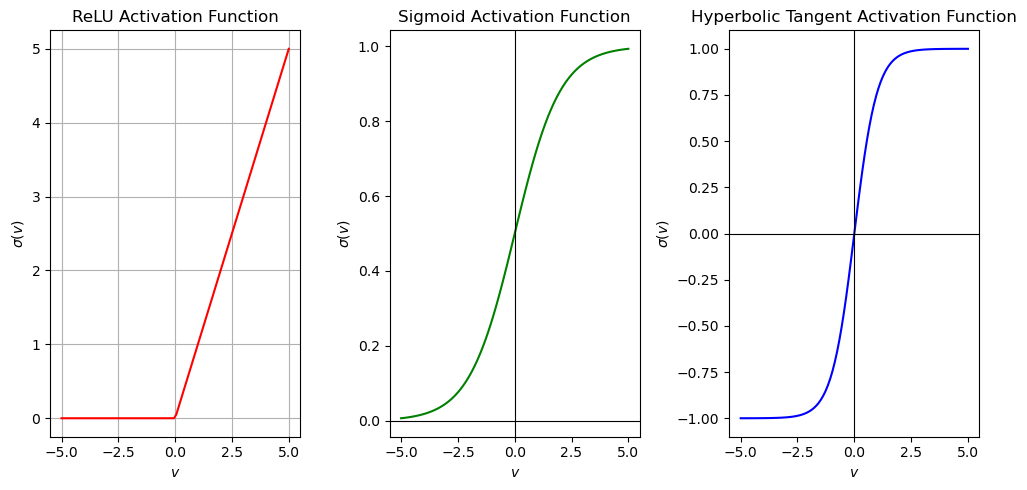

In [38]:
n = 100
v = np.linspace(-5, 5, n)

ReLU = lambda v : np.maximum(0, v)
Sigmoid = lambda v : 1 / (1 + np.exp(-v))
tanh = lambda v : 1 - 2 / (np.exp(2*v)+1)

plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.plot(v, ReLU(v),c="red")
plt.xlabel(r"$v$")
plt.ylabel(r"$\sigma(v)$")
plt.title("ReLU Activation Function")
plt.grid(True)


plt.subplot(1,3,2)
plt.plot(v, Sigmoid(v),c="green")
plt.xlabel(r"$v$")
plt.ylabel(r"$\sigma(v)$")
plt.title("Sigmoid Activation Function")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)


plt.subplot(1,3,3)
plt.plot(v, tanh(v),c="blue")
plt.xlabel(r"$v$")
plt.ylabel(r"$\sigma(v)$")
plt.title("Hyperbolic Tangent Activation Function")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)


plt.tight_layout()
plt.show()

<a class="anchor" id="one"></a>

# 3.1 Single hidden layer networks with one output neuron

**Single hidden layer networks with <u>one</u> Output neuron for Regression and binary classification**

- Input $x$ is a vector of shape $p \times 1$
- Collect all weights into a weight matrix $W$ of shape $p \times m$
$$
W = \begin{pmatrix} w_{1,1} & w_{1,2} & \ldots & w_{1,m} \\ 
w_{2,1} & w_{2,2} & \ldots & w_{2,m} \\
\vdots & \vdots & \ddots & \vdots \\
w_{p,1} & w_{p,2} & \ldots & w_{p,m}   
\end{pmatrix}
$$

- Obtain $z_1$ (neuron in hidden layer with bias term $b_1$) by picking the first column of $W$ which is $$W_1=\begin{pmatrix} w_{1,1} \\ w_{2,1} \\ \vdots \\ w_{p,1} \end{pmatrix}$$ and perform the affine transformation $W_1^\top x + b_1$ and then a non-linear transformation $\sigma(W_1^\top x + b_1)$ with the activation function $\sigma : \mathbb{R} \rightarrow \mathbb{R}$
- The single hidden layer networks with one output neuron has $m$ hidden neurons $z_1,\ldots,z_m$ in its hidden layer with $z_j = \sigma(W_j^\top x + b_j)$
    - $z_{\text{in},j}=W_j^\top x + b_j$ (affine transformation) for $j \in \{1,\ldots,m\}$
    - $z_{\text{out},j}=\sigma(z_{\text{in},j})=\sigma(W_j^\top x + b_j)$ (non-linear transformation) for $j \in \{1,\ldots,m\}$
- In vector notation it reads $z_{\text{in}}=(z_{\text{in},1},\ldots,z_{\text{in},m})^\top=W^\top x + b$ with $b=(b_1,\ldots,b_m)$
    - $z=z_{\text{out}}=\sigma(z_{\text{in}})=\sigma(W^\top x + b)$
    - the (hidden-layer) activation function $\sigma$ works element-wise on $z_{\text{in}}$
- For Regression or binary classification tasks with one output neuron the affine transformations in the hidden layer are computed as $f_{\text{in}}=u^\top z + c$ and the output is $f(x)=f_{\text{out}}=\tau(f_{\text{in}})=\tau(u^\top z + c)$ with output activation function $\tau$
    - For regression tasks $\tau$ is the identity function and for binary classification $\tau$ is the sigmoid function

&#128204; The hidden-layer activation function $\sigma$ is there to introduce non-linearities so the network can learn complex functions wheras $\tau$ is there to get the final score on the same scale as the target

- Multiple inputs
    - feed multiple inputs to a neural network simultaneously
    - Inputs $x^{(i)}$ for $i \in \{1,\ldots,n\}$ are collected as rows inside the desing matrix $X$ of shape $n \times p$
    - the affine transformation in the hidden layer is $XW + B$ with weights matrix $W$ of dimensions $p \times m$ and bias matrix B of dimensions $n \times m$ ($B$ contains the bias vector $b$ duplicated as rows)
    - the non-linear transformation is given by the matrix of hidden activations $Z=\sigma(XW + B)$ of dimensions $n \times m$
    - the final output of the output neuron contains predictions for each input $\tau(Zu + C)$ where $u$ is the vector of weights of the output neuron and $C$ of shape $n \times 1$ is a matrix whose elements are the bias $c$ of the output neuron


<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/21.png" width="550"/>
  <img src="pics/22.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/23.png" width="550"/>
  <img src="pics/24.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/25.png" width="550"/>
</div>

---
<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/26.png" width="550"/>
  <img src="pics/27.png" width="550"/>
</div>

---
<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/28.png" width="550"/>
  <img src="pics/29.png" width="550"/>
</div>

---
<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/30.png" width="550"/>
  <img src="pics/31.png" width="550"/>
</div>


### Why Nonlinear Activations Are Essential

**If hidden layers do not contain nonlinear activation functions, the entire network collapses into a single linear model and can only learn linear decision boundaries**

$$
f(x)=\tau(u^\top  \sigma(W^\top x))
$$

If $\sigma$ is simply the identity function:

$$
f(x)=\tau(u^\top W^\top x)
$$

which can be rewritten as:

$$
f(x)=\tau(v^\top x)
$$

for some vector $v = Wu$. It can be seen that $f(x)$ can only yield a linear decision boundary.


<a class="anchor" id="multiple"></a>

# 3.2 Single hidden layer networks with multiple output neurons 

**Single hidden layer networks with <u>multiple</u> output neurons for multiclass classification**


<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/32.png" width="550"/>
</div>

- Each neuron in the ouput layer represents a specific class so the number of neurons in the output layer is the number of classes
- $f=(f_1,\ldots,f_g)$ for $g$ output neurons
- Each of the $m$ hidden neurons $z_1,\ldots,z_m$ first compute the affine transformations $W_j^\top x$ (bias term omitted here) and then the non-linear transformations $z_j = \sigma(W_j^\top x), \quad \text{for } j = 1,\ldots,m \quad$ 
- Each output neuron first computes the affine transformations $f_{\text{in},k}=U_k^\top z$ where $z=(z_1,\ldots,z_m)^\top$ for every class $k=1,\ldots,g$ and then the non-linear transformations via the **softmax** activation function $$f_{\text{out},k}=\tau_k(f_{\text{in},k})=\frac{\exp(f_{\text{in},k})}{\sum_{k'=1}^g \exp(f_{\text{in},k'})}, \quad k=1,\ldots,g$$
- The softmax activation function gives a probability distribution (nonnegative and add up to 1) over the $g$ different classes
- Highest probability corresponds to predicted class

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/33.png" width="550"/>
</div>

--- 

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/34.png" width="550"/>
  <img src="pics/35.png" width="550"/>
</div>

--- 

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/36.png" width="550"/>
  <img src="pics/37.png" width="550"/>
</div>

--- 

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/38.png" width="550"/>
  <img src="pics/39.png" width="550"/>
</div>

--- 

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/40.png" width="550"/>
</div>


### Optimization: Softmax Loss

- The loss function for a softmax classifier is $$L(y,f(x))=-\sum_{k=1}^g [y=k] \log \left(\frac{\exp(f_{\text{in},k})}{\sum_{k'=1}^g \exp(f_{\text{in},k'})}\right) \quad \text{ where } [y=k] = \begin{cases} 1 &\text{ if }y=k, \\ 0 &\text{ otherwise} \end{cases}$$ 
- This equivalent to the cross-entropy loss when the label vector $y$ is one-hot encoded (e.g. $y=(0,1,0,0)^\top$)
- There is no analytical solution for the loss function for a softmax classifier


<a class="anchor" id="feedforward"></a>

# 3.3 Multi-layer feedforward networks

&#10071; Deep neural network used in Deep Learning

**Multi-layer feedforward networks with multiple hidden layers and output neurons.**
- Characterize Multi-layer feedforward networks by the following chain structure:
$$
f(x) = \tau \circ \phi \circ \sigma^{(l)} \circ \phi^{(l)} \circ \sigma^{(l-1)} \circ \phi^{(l-1)} \circ \ldots \circ \sigma^{(1)} \circ \phi^{(1)}
$$
- $\phi^{(i)}$ is the weighted sum (affine transformation) of hidden layer $i$
- $\sigma^{(i)}$ is the activation function (non-linear transformation) of hidden layer $i$
- $\phi$ is the the weighted sum (affine transformation) of the output layer
- $\tau$ is the the activation function (non-linear transformation) of the output layer
- Each hidden layer has an associated weights matrix $W^{(i)}$, bias $b^{(i)}$ and activation function $z^{(i)}$ for $i=1,\ldots,l$
- $z^{(i)}=\sigma^{(i)}(\phi^{(i)})=\sigma^{(i)}(W^{(i)^\top} z^{(i-1)} + b^{(i)})$ with $z^{(i-1)} $ being the previous hidden layer output and $z^{(0)}=x$
- If the activation functions $\sigma^{(i)}$ are linear then the entire network collapses into a single linear model and can only learn linear decision boundaries

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/41.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/43.png" width="550"/>
  <img src="pics/44.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/45.png" width="550"/>
  <img src="pics/46.png" width="550"/>
</div>


---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/47.png" width="550"/>
  <img src="pics/48.png" width="550"/>
</div>


---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/49.png" width="550"/>
  <img src="pics/50.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/51.png" width="550"/>
  <img src="pics/52.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/53.png" width="550"/>
  <img src="pics/54.png" width="550"/>
</div>

### Why add more hidden layers ?
- Multiple hidden layers allow more complex learning

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/42.png" width="550"/>
</div>

<a class="anchor" id="neural"></a>

# 4. Training Neural Networks

**Training consists of two repeated phases:**

### Forward Pass: Information flows through the network.
1. Input enters network
2. Hidden activations are computed
3. Output prediction is produced
4. Loss is computed

The loss measures prediction error.

### Backward Pass/Backpropogation: Information flows backward.

$\quad$**Goal: Determine how much each parameter contributed to the error.**

These contributions become gradients that tell us how to update weights.

<a class="anchor" id="loss"></a>

# 5. Loss Functions

**Regression**

$\quad$ Uses squared error: $$L(y,f(x))=\frac{1}{2}(y-f(x))^2$$

**Binary Classification**

$\quad$ Uses Bernoulli (cross-entropy) loss: $$L(y,f(x))=y\log(f(x))+(1-y)\log(1-f(x))$$

**The empirical risk over the training set is:** $$\mathcal{R}_\text{emp}=\sum_{i=1}^n L\left(y^{(i)},f(x^{(i)})\right)$$

Training attempts to minimize this quantity.

<a class="anchor" id="gradient"></a>

# 6. Gradient Descent

**Because neural network losses have no analytical solution, optimization uses gradient descent.**

Update rule: $$\theta^{[t+1]}=\theta^{[t]}-\alpha \nabla \mathcal{R}(\theta^{[t]})$$

where

- $\theta$ = all parameters
- $\alpha$ = learning rate (step size)
- $\nabla \mathcal{R}(\theta^{[t]})$ = gradient (direction of steepest ascent) at point $\theta^{[t]}$
- -$\nabla \mathcal{R}(\theta^{[t]})$ = direction of steepest descent at point $\theta^{[t]}$

<a class="anchor" id="SGD"></a>

# 7. Stochastic Gradient Descent (SGD)

Computing gradients over the entire dataset of size $n$ can be expensive.

Instead:

- randomly choose a minibatch (subset) of size $m$
- compute approximate gradient
- update parameters

One full pass through the dataset is called an epoch and consist of $\frac{n}{m}$ gradient updates.

**SGD algorithm:**
1. Initialize parameter vector $\theta^{[0]}$
2. $t \leftarrow 0$
3. <b>while</b> stopping criterion not met <b>do</b>
4. $\quad$ Randomly shuffle data and partition into minimatches $J_1,\ldots,J_K$ of size $m$
5. $\quad$ <b>for</b> $k \in \{1,\ldots,K\}$ <b>do</b>
6. $\quad$ $\quad$ $t \leftarrow t+1$
7. $\quad$ $\quad$ Compute gradient estimate with $J_k$:
7. $\quad$ $\quad$ $\quad$ $\hat{g}^{[t]} \leftarrow \frac{1}{m} \sum_{i \in J_k} \nabla_\theta L(y^{(i)},f(x^{(i)} \mid \theta^{[t-1]}))$
8. $\quad$ $\quad$ Apply update: $\theta^{[t]}=\theta^{[t-1]}-\alpha \hat{g}^{[t]}$
9. $\quad$ <b>end for</b>
10. <b>end while</b>

<a class="anchor" id="momentum"></a>

# 8. Momentum

**SGD can be slow. Momentum improves optimization by accumulating an exponentially weighted average of previous gradients.**

Benefits:
- faster convergence
- reduced oscillation
- smoother path through narrow valleys of the loss surface

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/55.png" width="550"/>
</div>

<a class="anchor" id="back"></a>

# 9. Backpropagation

### Backward pass/Backpropagation
- the information of the error that happened in the prediction of x flows backwards through the model
- calculate the error contribution of each weight to update weights by the negative gradient

Backpropagation is the algorithm used to efficiently compute gradients to update each weight $w \in \theta$ (and bias $b \in \mathbb{R}$).

>Backpropagation is simply the chain rule applied repeatedly on the weights which are stacked in layers inside the network.

### Backpropagation example (XOR example)
- randomly initialize weights $w$ and bias (usually bias is set to 0)
- as activations in both the hidden and output layers apply the logistic function $\frac{1}{1+\exp(-x)}$ for $\sigma$ and $\tau$
- feed the neural network with example $x=(1,0)^\top$ and $y=1$
- optimize the model using the squared error (L2 loss) between the binary 0-1 labels and the predicted probabilities (unusual in practice but easy computation)
- first compute Forward pass and get error of prediction
- compute the backward pass and apply backpropagation to update the weights using SGD $\left(\theta^{[t+1]}=\theta^{[t]}-\alpha \cdot \nabla_\theta L(y,f(x \mid \theta^{[t]}))\right)$
- Finally evaluate the model with our updated weights

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/56.png" width="550"/>
  <img src="pics/57.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/58.png" width="550"/>
  <img src="pics/59.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/60.png" width="550"/>
</div>

- The forwardpass predicted $f_\text{out}=0.7525$
- Compute the error of $f_\text{out}=0.7525$ and $y=1$
$$
\begin{align*}
L(y,f(x)) 
&= \frac{1}{2}\left(y-f(x^{(i)} \mid \theta)\right)^2 \\
&= \frac{1}{2} (y-f_\text{out})^2 \\
&= \frac{1}{2} (1-0.7525)^2 = 0.0306
\end{align*}
$$

**Backwardpass/Backward Propogation**
- reuse the results of the forward passwhich are her $z_{i,\text{in}},z_{i,\text{out}},f_{\text{in}} \text{ and }f_{\text{out}}$
- reuse the intermediate results during the backward pass due to the chain rule
- compute the derivatives of the activation functions and the affine transformations as well as $f_{\text{out}}$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/61.png" width="550"/>
  <img src="pics/62.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/63.png" width="550"/>
  <img src="pics/64.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/65.png" width="550"/>
  <img src="pics/66.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/67.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/68.png" width="550"/>
  <img src="pics/69.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/70.png" width="550"/>
  <img src="pics/71.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/72.png" width="550"/>
  <img src="pics/73.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/74.png" width="550"/>
  <img src="pics/75.png" width="550"/>
</div>


### Summary
- Our goal is to minimize the empirical risk  $\mathcal{R}_\text{emp}(\theta)=\frac{1}{n}\sum_{i=1}^n L(y^{(i)},f(x^{(i)} \mid \theta))$ with respect to the coefficients
- This is not possible since there is no way to find an analytical solution (global minimum) for deep neural networks
- Solve this by using gradient descent to iteratively find a local minimum of the loss function
- To perform gradient descent, we compute the gradient of the loss function Remp(θ) with respect to all the weights and biases in the 
- The number of components in the gradient is the total number of weights and biases in the network
- Apply the chainrule to the relevant portion of the computational graph to compute each component in the gradient
- In software implementations, a vectorized version of the chain rule is used to compute the derivatives with respect to multiple weights simultaneously
- After computing the gradient (using backpropagation), subtract the gradient (scaled by the learning-rate $\alpha$) from the current set of weights (and biases) which results in a new set of weights (and biases)
- The empirical loss for this new set of weights is now lower
- Next, once again compute the forward pass for this new set of weights and store the activations
- Then, compute the gradient of the empirical loss using backpropagation
- Repeat until the loss stops decreasing substantially
  - However, this naive approach often results in overfitting
  - Possible countermeasures include regularization and early stopping

<a class="anchor" id="example1"></a>

# 10. Example 1

**Single hidden-layer network with one output neuron for Regression**
$$
\begin{align*}
y(x)&=b_2 + W_2 \tanh(b_1 + W_1x) =
\begin{pmatrix} b_2 \\ b_2 \\ \vdots \\ b_2  \end{pmatrix} + W_2 \begin{bmatrix} \tanh((b_1 + W_1x)_1) \\ \tanh((b_1 + W_1x)_2)\\ \vdots \\ \tanh((b_1 + W_1x)_m)  \end{bmatrix}


\end{align*}
$$

Components
- Input vector $x \in \mathbb{R}^p$
- Weights matrix $W_1=\begin{pmatrix} w_{1,1} & w_{1,2} & \ldots & w_{1,p} \\ w_{2,1} & w_{2,2} & \ldots & w_{2,p} \\ \vdots & \vdots & \ddots & \vdots \\ w_{m,1} & w_{m,2} & \ldots & w_{m,p}   \end{pmatrix} \in \mathbb{R}^{m \times p}$  
- Bias vector $b_1 \in \mathbb{R}^m$
- Second weights matrix $W_2 \in \mathbb{R}^{k \times m}$
- Second bias vector $b_2 \in \mathbb{R}^k$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/76.jpg" width="550"/>
  <img src="pics/77.jpg" width="550"/>
</div>

---

**Multiple hidden-layer network with multiple output neuron**
$$
\begin{align*}
y(x)&=b_3 + W_3 \tanh(b_2 + W_2 \tanh(b_1 + W_1x)) 


\end{align*}
$$

Components
- Input vector $x \in \mathbb{R}^p$
- Weights matrix $W_1=\begin{pmatrix} w_{1,1} & w_{1,2} & \ldots & w_{1,p} \\ w_{2,1} & w_{2,2} & \ldots & w_{2,p} \\ \vdots & \vdots & \ddots & \vdots \\ w_{m,1} & w_{m,2} & \ldots & w_{m,p}   \end{pmatrix} \in \mathbb{R}^{m \times p}$  
- Bias vector $b_1 \in \mathbb{R}^m$
- Second weights matrix $W_2 \in \mathbb{R}^{k \times m}$
- Second bias vector $b_2 \in \mathbb{R}^k$
- Third weights matrix $W_3 \in \mathbb{R}^{r \times k}$
- Third bias vector $b_3 \in \mathbb{r}^r$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/78.jpg" width="550"/>
  <img src="pics/79.jpg" width="550"/>
</div>

### Forward pass:

```python
z1 = x                     # input layer              
z2 = np.tanh(b1 + W1 @ z1) # second layer (hidden)   
z3 = np.tanh(b2 + W2 @ z2) # third layer (hidden)    
z4 = b3 + W3 @ z3          # output layer
y  = z4                    # output
r  = y - t                 # residual
E  = 0.5 * r.T @ r         # suared error
```

### Parameters to be learned: $b_1, b_2, b_3, W_1, W_2, W_3$

$\quad \Rightarrow$ Compute gradient of $E$ with respect to those parameters

**Helper derivatives**

$$
\frac{d e^a}{d a} = e^a \frac{d}{d a} a \quad \text{ with Chain rule}  \\
\frac{d e^{(-a)}}{d a} = -e^{-a} \frac{d}{d a} a \quad \text{ with Chain rule}  \\
\frac{d (e^a + e^{-a})}{d a} = (e^a - e^{-a}) \frac{d}{d a} a \quad \text{ with Sum rule and Chain rule}  \\
\frac{d (e^a - e^{-a})}{d a} = (e^a + e^{-a}) \frac{d}{d a} a \quad \text{ with Sum rule and Chain rule}  \\
$$

**Derivative of $\tanh()$ scalar and vector version**

$$
\begin{align*}
\frac{d \tanh(a)}{d a} 
&= \frac{d }{d a} \frac{e^a - e^{-a}}{e^a + e^{-a}} \quad \mid \frac{d}{d a} \frac{u(a)}{v(a)} = \frac{\frac{d}{da}u(a)v(a) - u(a)\frac{d}{da}v(a)}{(v(a)^2)} \\
&= \frac{\frac{d }{d a}(e^a - e^{-a})(e^a + e^{-a}) - (e^a - e^{-a})\frac{d }{d a}(e^a + e^{-a})}{(e^a + e^{-a})^2} \\
&= \frac{(\frac{d }{d a}e^a - \frac{d }{d a}e^{-a})(e^a + e^{-a}) - (e^a - e^{-a})(\frac{d }{d a}e^a + \frac{d }{d a}e^{-a})}{(e^a + e^{-a})^2} \\
&= \frac{(e^a - e^{-a}(-\frac{d }{d a}a))(e^a + e^{-a}) - (e^a - e^{-a})(e^a + e^{-a}(-\frac{d }{d a}a))}{(e^a + e^{-a})^2} \\
&= \frac{(e^a + e^{-a}(\frac{d }{d a}a))(e^a + e^{-a}) - (e^a - e^{-a})(e^a - e^{-a}(\frac{d }{d a}a))}{(e^a + e^{-a})^2} \\
&= \frac{(e^a + e^{-a} \cdot 1)(e^a + e^{-a}) - (e^a - e^{-a})(e^a - e^{-a}\cdot 1)}{(e^a + e^{-a})^2} \\
&= \frac{(e^a + e^{-a})^2 - (e^a - e^{-a})^2}{(e^a + e^{-a})^2} \\
&= 1- \frac{(e^a - e^{-a})^2}{(e^a + e^{-a})^2} \\
&= 1- \tanh(a)^2 \quad \rightarrow \text{scalar version} \\

\text{For a vector }&v = (a_1, \ldots, a_d)^\top \\
\frac{d \tanh(a)}{d a} 
&= \frac{d}{d a} \begin{bmatrix} \tanh(a_1) \\ \vdots \\ \tanh(a_d) \end{bmatrix}  \\
&= \begin{bmatrix} \frac{d}{d a} \tanh(a_1) \\ \vdots \\ \frac{d}{d a} \tanh(a_d) \end{bmatrix}  \\
&= \begin{bmatrix} 1- \tanh(a_1)^2 \\ \vdots \\ 1- \tanh(a_d)^2 \end{bmatrix}  
= \text{Diag}(1-\tanh(v) \odot \tanh(v)) \quad \rightarrow \text{vector version}
\end{align*} 
$$

---

$$
\begin{align*}
\frac{\partial E}{\partial b_3} 
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial b_3} \quad \text{ since } b_3 \rightarrow y \rightarrow r \rightarrow E \\ 

&\frac{\partial E}{\partial r} = \frac{\partial }{\partial r} \frac{1}{2} r^\top r = \frac{1}{2} \frac{\partial }{\partial r} r^\top r = 2 \frac{1}{2} r = r  \\ 
&\frac{\partial r}{\partial y} = \frac{\partial }{\partial y} y-t = 1 \\
&\frac{\partial y}{\partial b_3} = \frac{\partial }{\partial b_3} z_4 = \frac{\partial }{\partial b_3} b_3 + W_3 z_3 = 1 \\
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial b_3}  \\
&= r \cdot 1 \cdot 1 = r
\end{align*}
$$



$$
\begin{align*}
\frac{\partial E}{\partial W_3} 
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial W_3} \quad \text{ since } W_3 \rightarrow y \rightarrow r \rightarrow E \\ 

&\frac{\partial E}{\partial r} = \frac{\partial }{\partial r} \frac{1}{2} r^\top r = \frac{1}{2} \frac{\partial }{\partial r} r^\top r = 2 \frac{1}{2} r = r  \\ 
&\frac{\partial r}{\partial y} = \frac{\partial }{\partial y} y-t = 1 \\
&\frac{\partial y}{\partial W_3} = \frac{\partial }{\partial W_3} z_4 = \frac{\partial }{\partial W_3} b_3 + W_3 z_3 = z_3 \\
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial b_3}  \\
&= r \cdot 1 \cdot z_3^\top = rz_3^\top
\end{align*}
$$

---

$$
\begin{align*}
\frac{\partial E}{\partial b_2} 
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial z_3} \frac{\partial z_3}{\partial b_2}  \quad \text{ since } b_2 \rightarrow z_3 \rightarrow y \rightarrow r \rightarrow E \\ 

&\frac{\partial E}{\partial r} = \frac{\partial }{\partial r} \frac{1}{2} r^\top r = \frac{1}{2} \frac{\partial }{\partial r} r^\top r = 2 \frac{1}{2} r = r  \\ 
&\frac{\partial r}{\partial y} = \frac{\partial }{\partial y} y-t = 1 \\
&\frac{\partial y}{\partial z_3} = \frac{\partial }{\partial z_3} z_4 = \frac{\partial }{\partial z_3} b_3 + W_3 z_3 = W_3 \\
&\frac{\partial z_3}{\partial b_2} = \frac{\partial z_3}{\partial a_3} \frac{\partial a_3}{\partial b_2} =\text{Diag}(1-z_3^2) \cdot 1 \quad \text{ since }z_3 = \tanh(a_3), a_3 = b_2 + W_2z_2 \\
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial z_3} \frac{\partial z_3}{\partial b_2}  \\
&= \text{Diag}(1-z_3^2)W_3^\top r
\end{align*}
$$




$$
\begin{align*}
\frac{\partial E}{\partial W_2} 
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial z_3} \frac{\partial z_3}{\partial W_2}  \quad \text{ since } W_2 \rightarrow z_3 \rightarrow y \rightarrow r \rightarrow E \\ 

&\frac{\partial E}{\partial r} = \frac{\partial }{\partial r} \frac{1}{2} r^\top r = \frac{1}{2} \frac{\partial }{\partial r} r^\top r = 2 \frac{1}{2} r = r  \\ 
&\frac{\partial r}{\partial y} = \frac{\partial }{\partial y} y-t = 1 \\
&\frac{\partial y}{\partial z_3} = \frac{\partial }{\partial z_3} z_4 = \frac{\partial }{\partial z_3} b_3 + W_3 z_3 = W_3 \\
&\frac{\partial z_3}{\partial W_2} = \frac{\partial z_3}{\partial a_3} \frac{\partial a_3}{\partial W_2} =\text{Diag}(1-z_3^2) z_2 \quad \text{ since }z_3 = \tanh(a_3), a_3 = b_2 + W_2z_2 \\
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial z_3} \frac{\partial z_3}{\partial W_2}  \\
&= \text{Diag}(1-z_3^2)W_3^\top r z_2^\top
\end{align*}
$$



---

$$
\begin{align*}
\frac{\partial E}{\partial b_1} 
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial z_3} \frac{\partial z_3}{\partial z_2} \frac{\partial z_2}{\partial b_1}  \quad \text{ since } b_1 \rightarrow z_2 \rightarrow z_3 \rightarrow y \rightarrow r \rightarrow E \\ 
&\frac{\partial E}{\partial r} = \frac{\partial }{\partial r} \frac{1}{2} r^\top r = \frac{1}{2} \frac{\partial }{\partial r} r^\top r = 2 \frac{1}{2} r = r  \\ 
&\frac{\partial r}{\partial y} = \frac{\partial }{\partial y} y-t = 1 \\
&\frac{\partial y}{\partial z_3} = \frac{\partial }{\partial z_3} z_4 = \frac{\partial}{\partial z_3} b_3 + W_3 z_3 = W_3 \\
&\frac{\partial z_3}{\partial z_2} = \frac{\partial z_3}{\partial a_3} \frac{\partial a_3}{\partial z_2} =\text{Diag}(1-z_3^2)W_2 \quad \text{ since }z_3 = \tanh(a_3), a_3 = b_2 + W_2z_2 \\
&\frac{\partial z_2}{\partial b_1} = \frac{\partial z_2}{\partial a_2} \frac{\partial a_2}{\partial b_1} = \text{Diag}(1-z_2^2) \cdot 1 \quad \text{ since }z_2 = \tanh(a_2), a_2 = b_1 + W_1z_1 \\
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial z_3} \frac{\partial z_3}{\partial z_2} \frac{\partial z_2}{\partial b_1}  \\
&= \text{Diag}(1-z_2^2)W_2^\top \text{Diag}(1-z_3^2)W_3^\top r
\end{align*}
$$

$$
\begin{align*}
\frac{\partial E}{\partial W_1} 
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial z_3} \frac{\partial z_3}{\partial z_2} \frac{\partial z_2}{\partial W_1}  \quad \text{ since } W_1 \rightarrow z_2 \rightarrow z_3 \rightarrow y \rightarrow r \rightarrow E \\ 
&\frac{\partial E}{\partial r} = \frac{\partial }{\partial r} \frac{1}{2} r^\top r = \frac{1}{2} \frac{\partial }{\partial r} r^\top r = 2 \frac{1}{2} r = r  \\ 
&\frac{\partial r}{\partial y} = \frac{\partial }{\partial y} y-t = 1 \\
&\frac{\partial y}{\partial z_3} = \frac{\partial }{\partial z_3} z_4 = \frac{\partial}{\partial z_3} b_3 + W_3 z_3 = W_3 \\
&\frac{\partial z_3}{\partial z_2} = \frac{\partial z_3}{\partial a_3} \frac{\partial a_3}{\partial z_2} =\text{Diag}(1-z_3^2)W_2 \quad \text{ since }z_3 = \tanh(a_3), a_3 = b_2 + W_2z_2 \\
&\frac{\partial z_2}{\partial W_1} = \frac{\partial z_2}{\partial a_2} \frac{\partial a_2}{\partial W_1} = \text{Diag}(1-z_2^2) z_1 \quad \text{ since }z_2 = \tanh(a_2), a_2 = b_1 + W_1z_1 \\
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial z_3} \frac{\partial z_3}{\partial z_2} \frac{\partial z_2}{\partial b_1}  \\
&= \text{Diag}(1-z_2^2)W_2^\top \text{Diag}(1-z_3^2)W_3^\top r z_1^\top
\end{align*}
$$

---

$$
\begin{align}
\nabla_{b_3} E
&= r \\[6pt]

\nabla_{W_3} E
&= r\, z_3^{\top} \\[6pt]

\nabla_{b_2} E
&= \color{green}\operatorname{Diag}\!\left(1-z_3^2\right)\, W_3^{\top}\, r\color{white} \\[6pt]

\nabla_{W_2} E
&= \color{green}\operatorname{Diag}\!\left(1-z_3^2\right)\, W_3^{\top}\, r\color{white}\, z_2^{\top} \\[6pt]

\nabla_{b_1} E
&= \color{orange}\operatorname{Diag}\!\left(1-z_2^2\right)\,
   W_2^{\top}\,
   \operatorname{Diag}\!\left(1-z_3^2\right)\,
   W_3^{\top}\,
   r\color{white} \\[6pt]

\nabla_{W_1} E
&= \color{orange}\operatorname{Diag}\!\left(1-z_2^2\right)\,
   W_2^{\top}\,
   \operatorname{Diag}\!\left(1-z_3^2\right)\,
   W_3^{\top}\,
   r\color{white}\,
   z_1^{\top}
\end{align}
$$

### Backward pass with Gradient Descent:


<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

$$
b_1 = b_1 - \text{learning\_rate} \cdot \frac{\partial E}{\partial b_1} \\[2 mm]
W_1 = W_1 - \text{learning\_rate} \cdot \frac{\partial E}{\partial W_1} \\[2 mm]
$$


</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

$$
b_2 = b_2 - \text{learning\_rate} \cdot \frac{\partial E}{\partial b_2} \\[2 mm]
W_2 = W_2 - \text{learning\_rate} \cdot \frac{\partial E}{\partial W_2} \\[2 mm]
$$

</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

$$
b_3 = b_3 - \text{learning\_rate} \cdot \frac{\partial E}{\partial b_3} \\[2 mm]
W_3 = W_3 - \text{learning\_rate} \cdot \frac{\partial E}{\partial W_3} \\
$$

</div>
</div>

In [39]:
np.random.seed(1300)

# Network dimensions
p = 2   # input dimension
m = 4   # hidden layer 1
k = 3   # hidden layer 2
r = 1   # output dimension

learning_rate = 0.01

# Parameters
W1 = np.random.randn(m, p) * 0.1
b1 = np.zeros(m)

W2 = np.random.randn(k, m) * 0.1
b2 = np.zeros(k)

W3 = np.random.randn(r, k) * 0.1
b3 = np.zeros(r)


# Training sample
x = np.array([0.5, -1.2])
t = np.array([1.0])


# Training loop
for epoch in range(1000):

    # Forward pass
    z1 = x

    a2 = b1 + W1 @ z1
    z2 = np.tanh(a2)

    a3 = b2 + W2 @ z2
    z3 = np.tanh(a3)

    z4 = b3 + W3 @ z3

    y = z4

    r_vec = y - t

    E = 0.5 * r_vec.T @ r_vec


    # Backward pass

    # dE/db3 = r
    dE_db3 = r_vec

    # dE/dW3 = r z3^T
    dE_dW3 = np.outer(r_vec, z3)

    # dE/db2
    dE_db2 = (1.0 - z3**2) * (W3.T @ r_vec)

    # dE/dW2
    dE_dW2 = np.outer(dE_db2, z2)

    # dE/db1
    dE_db1 = (1.0 - z2**2) * (W2.T @ dE_db2)

    # dE/dW1
    dE_dW1 = np.outer(dE_db1, z1)


    # Gradient descent update
    b1 -= learning_rate * dE_db1
    W1 -= learning_rate * dE_dW1

    b2 -= learning_rate * dE_db2
    W2 -= learning_rate * dE_dW2

    b3 -= learning_rate * dE_db3
    W3 -= learning_rate * dE_dW3

    if epoch % 100 == 0:
        print(f"epoch={epoch:4d}  loss={E:.6f}")

print("\nPrediction:")
print(y)
print("Target:")
print(t)

epoch=   0  loss=0.499986
epoch= 100  loss=0.066873
epoch= 200  loss=0.008928
epoch= 300  loss=0.001190
epoch= 400  loss=0.000159
epoch= 500  loss=0.000021
epoch= 600  loss=0.000003
epoch= 700  loss=0.000000
epoch= 800  loss=0.000000
epoch= 900  loss=0.000000

Prediction:
[0.99995748]
Target:
[1.]


0 27.446898103643253
500 0.07245472031129366
1000 0.07033206740805087
1500 0.06689510154921595


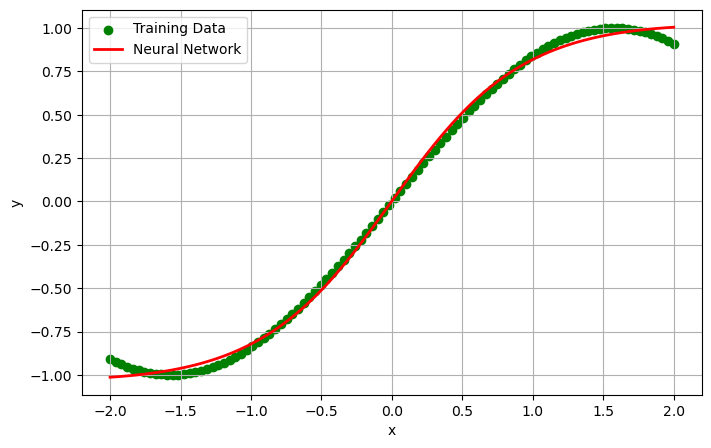

In [40]:
np.random.seed(1300)

# Network dimensions
p = 1   # input dimension
m = 4   # hidden layer 1
k = 3   # hidden layer 2
r = 1   # output dimension

learning_rate = 0.01

# Parameters
W1 = np.random.randn(m, p) * 0.1
b1 = np.zeros(m)

W2 = np.random.randn(k, m) * 0.1
b2 = np.zeros(k)

W3 = np.random.randn(r, k) * 0.1
b3 = np.zeros(r)


X = np.linspace(-2, 2, 100).reshape(-1, 1)

# nonlinear target function
T = np.sin(X)

for epoch in range(2000):

    total_loss = 0

    for x, t in zip(X, T):

        z1 = x

        a2 = b1 + W1 @ z1
        z2 = np.tanh(a2)

        a3 = b2 + W2 @ z2
        z3 = np.tanh(a3)

        y = b3 + W3 @ z3

        r_vec = y - t
        E = 0.5 * r_vec.T @ r_vec

        total_loss += E

        # backprop
        dE_db3 = r_vec
        dE_dW3 = np.outer(r_vec, z3)

        dE_db2 = (1 - z3**2) * (W3.T @ r_vec)
        dE_dW2 = np.outer(dE_db2, z2)

        dE_db1 = (1 - z2**2) * (W2.T @ dE_db2)
        dE_dW1 = np.outer(dE_db1, z1)

        # update
        b1 -= learning_rate * dE_db1
        W1 -= learning_rate * dE_dW1

        b2 -= learning_rate * dE_db2
        W2 -= learning_rate * dE_dW2

        b3 -= learning_rate * dE_db3
        W3 -= learning_rate * dE_dW3

    if epoch % 500 == 0:
        print(epoch, total_loss)

Y_pred = []

for x in X:

    z1 = x

    a2 = b1 + W1 @ z1
    z2 = np.tanh(a2)

    a3 = b2 + W2 @ z2
    z3 = np.tanh(a3)

    y = b3 + W3 @ z3

    Y_pred.append(y.item())

Y_pred = np.array(Y_pred)

plt.figure(figsize=(8,5))
plt.scatter(X, T, label="Training Data",color="green")

plt.plot(X, Y_pred,linewidth=2,label="Neural Network",color="red")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.show()

<a class="anchor" id="example2"></a>

# 11. Example 2

Consider following multiple hidden-layer neural network with on output neuron

$$
y=f_3(w_3, f_2(w_2,f_1(w_1,x))) 
$$

- $x$ and $y$ are scalars
- $w_1,w_2,w_3$ are parameters to be learned
- Evaluate with squarred loss $E=\frac{1}{2}(y-t)^2$
- Goal: Minimize $E$ with respect to $w_1,w_2,w_3$ so $\underset{w_1,w_2,w_3}{\min}E$
- Choose $f_i(w_i,z_i)=\tanh(w_iz_i)$

```python
z1 = x               # input layer              
z2 = tanh(w1*z1)     # second layer (hidden)   
z3 = tanh(w2*z2)     # third layer (hidden)    
z4 = tanh(w3*z3)     # output layer
r  = z4 - t          # residual
E  = 0.5 * r.T @ r   # suared error
```

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/80_.png" width="700"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/81.png" width="700"/>
</div>

$$
\begin{align*}
\frac{\partial E}{\partial E} &= 1 \\
\frac{\partial E}{\partial z_4} &= z_4-t = r \\
\end{align*}
$$

$$
\begin{align*}
\frac{\partial E}{\partial w_3} &= \frac{\partial E}{\partial z_4} \frac{\partial z_4}{\partial w_3} = r(1-z_4^2)z_3  \\
\frac{\partial E}{\partial z_3} &= \frac{\partial E}{\partial z_4} \frac{\partial z_4}{\partial z_3} = r(1-z_4^2)w_3  \\
\end{align*}
$$

$$
\begin{align*}
\frac{\partial E}{\partial w_2} &= \frac{\partial E}{\partial z_3} \frac{\partial z_3}{\partial w_2}=r(1-z_4^2)w_3(1-z_3^2)z_2  \\
\frac{\partial E}{\partial z_2} &= \frac{\partial E}{\partial z_3} \frac{\partial z_3}{\partial z_2}=r(1-z_4^2)w_3(1-z_3^2)w_2  \\
\end{align*}
$$

$$
\begin{align*}
\frac{\partial E}{\partial w_1} &= \frac{\partial E}{\partial z_2} \frac{\partial z_2}{\partial w_1}=r(1-z_4^2)w_3(1-z_3^2)w_2(1-z_2^2)z_1  \\
\end{align*}
$$

**Gradient updates**
$$
w_3 \leftarrow w_3 - \eta \frac{\partial E}{\partial w_3}, \quad
w_2 \leftarrow w_2 - \eta \frac{\partial E}{\partial w_2}, \quad
w_1 \leftarrow w_1 - \eta \frac{\partial E}{\partial w_1} \\
$$

In [41]:
np.random.seed(1848)

w1 = np.random.randn()
w2 = np.random.randn()
w3 = np.random.randn()

def forward(x, t, w1, w2, w3):
    z1 = x
    z2 = np.tanh(w1 * z1)
    z3 = np.tanh(w2 * z2)
    z4 = np.tanh(w3 * z3)
    r = z4 - t
    E = 0.5 * r**2

    return z1, z2, z3, z4, r, E


def backward(x, t, w1, w2, w3, lr=0.1):
    z1, z2, z3, z4, r, E = forward(x, t, w1, w2, w3)
    sub1 = r * (1 - z4**2)
    dEdw3 = sub1 * z3
    sub2 = (1 - z3**2)
    dEdw2 = sub1 * w3 * sub2 * z2
    dEdw1 = sub1 * w3 * sub2 * w2 * (1 - z2**2) * z1

    w3 -= lr * dEdw3
    w2 -= lr * dEdw2
    w1 -= lr * dEdw1
    return w1, w2, w3, E

x = 0.5
t = 1.0

for epoch in range(1000):
    w1, w2, w3, E = backward(x, t, w1, w2, w3)
    if epoch % 100 == 0:
        print(epoch, E)

0 0.5000720214863305
100 0.49952416626609797
200 0.4946294369771923
300 0.061757127188732594
400 0.007527811623547166
500 0.0036837970638847802
600 0.0024018992765618328
700 0.0017717238946525708
800 0.0013995509412624359
900 0.0011547265769411262


In [42]:
np.random.seed(1848)

# Network dimension
p = 3

# Weight matrices
W1 = np.random.randn(p, p)
W2 = np.random.randn(p, p)
W3 = np.random.randn(p, p)

# Single training sample
x = np.random.randn(p)
t = np.random.randn(p)


def forward(x, t, W1, W2, W3):

    z1 = x
    z2 = np.tanh(W1 @ z1)
    z3 = np.tanh(W2 @ z2)
    z4 = np.tanh(W3 @ z3)
    r = z4 - t
    E = 0.5 * (r @ r)
    return z1, z2, z3, z4, r, E


def backward(x, t, W1, W2, W3, lr=0.01):
    z1, z2, z3, z4, r, E = forward(x, t, W1, W2, W3)

    # Output layer delta
    delta4 = r * (1.0 - z4**2)

    # Hidden layer deltas
    delta3 = (W3.T @ delta4) * (1.0 - z3**2)
    delta2 = (W2.T @ delta3) * (1.0 - z2**2)

    # Weight gradients
    dEdW3 = np.outer(delta4, z3)
    dEdW2 = np.outer(delta3, z2)
    dEdW1 = np.outer(delta2, z1)

    # Gradient descent
    W3 -= lr * dEdW3
    W2 -= lr * dEdW2
    W1 -= lr * dEdW1

    return W1, W2, W3, E


# Training loop
for epoch in range(1000):

    W1, W2, W3, E = backward(x, t,W1, W2, W3,lr=0.01)

    if epoch % 100 == 0:
        print(f"epoch={epoch:4d}, loss={E:.6f}")


# Final prediction
z1, z2, z3, z4, r, E = forward(x, t,W1, W2, W3)

print("\nPrediction:")
print(z4)

print("\nTarget:")
print(t)

print("\nFinal loss:")
print(E)

epoch=   0, loss=1.105589
epoch= 100, loss=0.584248
epoch= 200, loss=0.306463
epoch= 300, loss=0.172139
epoch= 400, loss=0.127838
epoch= 500, loss=0.110286
epoch= 600, loss=0.101376
epoch= 700, loss=0.095973
epoch= 800, loss=0.092323
epoch= 900, loss=0.089683

Prediction:
[-0.40270821 -0.96255166  0.09956169]

Target:
[-0.43250642 -1.38020368  0.105998  ]

Final loss:
0.08768128446393347


<a class="anchor" id="example3"></a>

# 12. Example 3

Consider following multiple hidden-layer neural network with one output neuron.

$$
f(w,x)=\frac{1}{1+\exp(-(w_0x_0+w_1x_1+w_2))}
$$

- $a=w_0x_0$
- $b=w_1x_1$
- $c=a+b$
- $d=c+w_2$
- $e=-d$
- $f=\exp(e)$
- $g=1+f$
- $y=\frac{1}{g}$

- With binary cross-entropy loss $E=-(t \log(y) + (1-t) \log(1-y))$

### Forward pass

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/82.png" width="700"/>
</div>

$$
\begin{align*}
\frac{\partial E}{\partial w_0} &= \frac{\partial E}{\partial y}\frac{\partial y}{\partial g}\frac{\partial g}{\partial f}\frac{\partial f}{\partial e}\frac{\partial e}{\partial d}\frac{\partial d}{\partial c}\frac{\partial c}{\partial a}\frac{\partial a}{\partial w_0} \\


\frac{\partial E}{\partial w_1} &= \frac{\partial E}{\partial y}\frac{\partial y}{\partial g}\frac{\partial g}{\partial f}\frac{\partial f}{\partial e}\frac{\partial e}{\partial d}\frac{\partial d}{\partial c}\frac{\partial c}{\partial b}\frac{\partial b}{\partial w_1} \\


\frac{\partial E}{\partial w_2} &= \frac{\partial E}{\partial y}\frac{\partial y}{\partial g}\frac{\partial g}{\partial f}\frac{\partial f}{\partial e}\frac{\partial e}{\partial d}\frac{\partial d}{\partial w_2} \\
\end{align*}
$$

---

$$\frac{\partial E}{\partial y} = \frac{\partial}{\partial y}(-(t \log(y) + (1-t) \log(1-y))) = -\frac{t}{y} + \frac{1-t}{1-y}$$
$$\frac{\partial y}{\partial g} = \frac{\partial}{\partial g}\frac{1}{g} = -\frac{1}{g^2}$$
$$\frac{\partial g}{\partial f} = \frac{\partial}{\partial f}1+f = 1$$
$$\frac{\partial f}{\partial e} = \frac{\partial}{\partial e}\exp(e) = \exp(e) = f$$
$$\frac{\partial e}{\partial d} = \frac{\partial}{\partial d}-d = -1$$
$$\frac{\partial d}{\partial c} = \frac{\partial}{\partial c}c+w_2 = 1$$
$$\frac{\partial d}{\partial w_2} = \frac{\partial}{\partial c}c+w_2 = 1$$
$$\frac{\partial c}{\partial a} = \frac{\partial}{\partial a}a+b = 1$$
$$\frac{\partial c}{\partial b} = \frac{\partial}{\partial a}a+b = 1$$
$$\frac{\partial a}{\partial w_0} = \frac{\partial}{\partial w_0}w_0x_0 = x_0$$
$$\frac{\partial b}{\partial w_1} = \frac{\partial}{\partial w_1}w_1x_1 = x_1$$


---

$$
\begin{align*}
\frac{\partial E}{\partial w_0} &= \frac{\partial E}{\partial y}\frac{\partial y}{\partial g}\frac{\partial g}{\partial f}\frac{\partial f}{\partial e}\frac{\partial e}{\partial d}\frac{\partial d}{\partial c}\frac{\partial c}{\partial a}\frac{\partial a}{\partial w_0} \\
&= (-\frac{t}{y} + \frac{1-t}{1-y})(-\frac{1}{g^2})(1)f(-1)(1)(1)x_0 \\
&=(-\frac{t}{y} + \frac{1-t}{1-y})\frac{f}{g^2}x_0  \\
((y = \frac{1}{g} \iff g = \frac{1}{y}) \text{ und } (g = 1+f &\iff f = g-1)) \Rightarrow f = \frac{1}{y} - 1 = \frac{1-y}{y}\quad\text{und}\quad  
\frac{f}{g^2} = \frac{\frac{1-y}{y}}{\frac{1}{y^2}}&=y(1-y) \\
&=(-\frac{t}{y} + \frac{1-t}{1-y})y(1-y)x_0  \\
&=(-\frac{t}{y}y(1-y) + \frac{1-t}{1-y}y(1-y))x_0  \\
&=(-t(1-y) + (1-t)y)x_0  \\
&=(-t+ty + y-ty)x_0  \\
&=(y-t)x_0  \\
\end{align*}
$$

$$
\begin{align*}
\frac{\partial E}{\partial w_1} &= \frac{\partial E}{\partial y}\frac{\partial y}{\partial g}\frac{\partial g}{\partial f}\frac{\partial f}{\partial e}\frac{\partial e}{\partial d}\frac{\partial d}{\partial c}\frac{\partial c}{\partial b}\frac{\partial b}{\partial w_1} \\
&=(-\frac{t}{y} + \frac{1-t}{1-y})(-\frac{1}{g^2})(1)f(-1)(1)(1)x_1 \\
&=(-\frac{t}{y} + \frac{1-t}{1-y})(\frac{f}{g^2})x_1 \\
&=(y-t)x_1 \\
\end{align*}
$$

$$
\begin{align*}
\frac{\partial E}{\partial w_2} &= \frac{\partial E}{\partial y}\frac{\partial y}{\partial g}\frac{\partial g}{\partial f}\frac{\partial f}{\partial e}\frac{\partial e}{\partial d}\frac{\partial d}{\partial w_2} \\
&=(-\frac{t}{y} + \frac{1-t}{1-y})(-\frac{1}{g^2})(1)f(-1)(1) \\
&=(-\frac{t}{y} + \frac{1-t}{1-y})(\frac{f}{g^2}) \\
&=y-t \\
\end{align*}
$$

### Backward pass
<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/83.png" width="700"/>
</div>

**There is a much simpler derivative**

Because
$$
y = \sigma(d) = \frac{1}{1+\exp(-d)}
$$
and
$$
E=-(t \log(y) + (1-t) \log(1-y))
$$
the sigmoid and binary cross-entropy combine beautifully.
First,
$$
\frac{\partial E}{\partial y} = -\frac{t}{y} + \frac{1-t}{1-y}.
$$
Also,
$$
\frac{\partial y}{\partial d} = y(1-y).
$$
Multiplying:
$$
\frac{\partial E}{\partial d}=(-\frac{t}{y} + \frac{1-t}{1-y})y(1-y)
$$
Everything simplifies to
$$
\frac{\partial E}{\partial d}=y-t
$$
This is one of the most important identities in machine learning.

#### Final gradients

Since

$$
d=w_0x_0+w_1x_1+w_2
$$

we have

$$
\frac{d}{d w_0}=x_0, \quad \frac{d}{d w_1}=x_1, \quad \frac{d}{d w_2}=1
$$

Therefore

$$
\frac{\partial E}{\partial w_0}=(y-t)x_0 \\[1.5 mm]
\frac{\partial E}{\partial w_1}=(y-t)x_1 \\[1.5 mm]
\frac{\partial E}{\partial w_2}=y-t \\
$$


In [43]:
np.random.seed(2013)

def forward_pass(w, x, t):

    w0, w1, w2 = w
    x0, x1 = x

    a = w0 * x0
    b = w1 * x1
    c = a + b
    d = c + w2

    y = 1.0 / (1.0 + np.exp(-d))

    E = -(t * np.log(y) + (1 - t) * np.log(1 - y))

    return y, E


def backward_pass(w, x, t, lr=0.1):

    w0, w1, w2 = w
    x0, x1 = x

    y, E = forward_pass(w, x, t)

    # BCE + sigmoid gradient
    delta = y - t

    dEdw0 = delta * x0
    dEdw1 = delta * x1
    dEdw2 = delta

    w0 -= lr * dEdw0
    w1 -= lr * dEdw1
    w2 -= lr * dEdw2

    w = np.array([w0, w1, w2])

    return w, E

# input
x = np.array([2.0, -1.0])

# binary target
t = 1.0

# parameters
w = np.random.randn(3)

for epoch in range(1000):

    w, E = backward_pass(w, x, t, lr=0.1)

    if epoch % 100 == 0:
        print(f"epoch={epoch:4d}, loss={E:.6f}")


y, E = forward_pass(w, x, t)
print("\nFinal prediction:", y)
print("Target:", t)

epoch=   0, loss=0.286569
epoch= 100, loss=0.016303
epoch= 200, loss=0.008274
epoch= 300, loss=0.005538
epoch= 400, loss=0.004160
epoch= 500, loss=0.003331
epoch= 600, loss=0.002777
epoch= 700, loss=0.002381
epoch= 800, loss=0.002084
epoch= 900, loss=0.001853

Final prediction: 0.9983339879002847
Target: 1.0


<a class="anchor" id="example4"></a>

# 13. Example 4

$$
f(x,y,w,z)=2(xy+\max(z,w))
$$

- $a=x \cdot y \rightarrow $ mul gate 
- $b=\max(z,w)$
- $c=a+b \rightarrow $ add gate
- $d=2c \rightarrow $ mul gate
- $L=\frac{1}{2}(d-t)^2$ squarred loss


<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/84.png" width="700"/>
</div>

$$
\begin{align*}
\frac{\partial L}{\partial x} &=\frac{\partial L}{\partial L} \frac{\partial L}{\partial d} \frac{\partial d}{\partial c} \frac{\partial c}{\partial a}\frac{\partial a}{\partial x} = (1) \cdot (d-t) \cdot  \underbrace{(2)}_{\underset{d=2c}{\text{mul gate}}} \cdot  \underbrace{(1)}_{\underset{c=a+b}{\text{add gate}}} \cdot \underbrace{(y)}_{\underset{a=xy}{\text{mul gate}}} = 2(d-t)y   \\

\frac{\partial L}{\partial y} &=\frac{\partial L}{\partial L} \frac{\partial L}{\partial d} \frac{\partial d}{\partial c} \frac{\partial c}{\partial a}\frac{\partial a}{\partial y} = (1) \cdot (d-t) \cdot  \underbrace{(2)}_{\underset{d=2c}{\text{mul gate}}} \cdot  \underbrace{(1)}_{\underset{c=a+b}{\text{add gate}}} \cdot \underbrace{(x)}_{\underset{a=xy}{\text{mul gate}}} = 2(d-t)x   \\


&\frac{\partial \max(z,w)}{\partial z} = \begin{cases} 1 &, z>w \\ 0 &, z < w \end{cases}, \quad 
\frac{\partial \max(z,w)}{\partial w} = \begin{cases} 1 &, w>z \\ 0 &, w < z \end{cases} \\

\\

\frac{\partial L}{\partial z} &=\frac{\partial L}{\partial L} \frac{\partial L}{\partial d} \frac{\partial d}{\partial c} \frac{\partial c}{\partial b}\frac{\partial b}{\partial z} = (1) \cdot (d-t) \cdot  \underbrace{(2)}_{\underset{d=2c}{\text{mul gate}}} \cdot  \underbrace{(1)}_{\underset{c=a+b}{\text{add gate}}} \cdot \underbrace{(\mathcal{1}_{\{z>w\}})}_{\underset{b=\max(z,w)}{\text{max gate}}} = 2(d-t)\mathcal{1}_{\{z>w\}}   \\

\frac{\partial L}{\partial w} &=\frac{\partial L}{\partial L} \frac{\partial L}{\partial d} \frac{\partial d}{\partial c} \frac{\partial c}{\partial b}\frac{\partial b}{\partial w} = (1) \cdot (d-t) \cdot  \underbrace{(2)}_{\underset{d=2c}{\text{mul gate}}} \cdot  \underbrace{(1)}_{\underset{c=a+b}{\text{add gate}}} \cdot \underbrace{(\mathcal{1}_{\{w>z\}})}_{\underset{b=\max(z,w)}{\text{max gate}}} = 2(d-t)\mathcal{1}_{\{w>z\}}   \\
\end{align*}
$$

### Gate interpretations in this example

- Squared loss: produces the initial gradient $$\frac{\partial L}{\partial d}=(d-t)$$

- Mul gate $d=2c$: multiplies every incoming gradient by 2
- Add gate $c=a+b$: copies the gradient unchanged to both branches: $$\frac{\partial c}{\partial a} = 1 \quad \frac{\partial c}{\partial b}=1$$
- Mul gate $a=xy$: switches gradients: $$\frac{\partial a}{\partial x} = y \quad \frac{\partial a}{\partial y}=x$$
- Max gate $b=\max(z,w)$: routes the gradient only to the larger input:$$\frac{\partial b}{\partial z} \in \{0,1\} \quad \frac{\partial b}{\partial w}\in \{0,1\}$$

This makes the backward flow easy to visualize:

$$
(d-t) \overset{\text{mul }\times 2}{\longrightarrow} 2(d-t) \overset{\text{add}}{\longrightarrow} \begin{cases} \text{mul gate}(xy)\\\text{max gate}(\max(z,w)) \end{cases}
$$

In [44]:
np.random.seed(1556)

x, y, z, w = np.random.rand(4)
print(f"Initial values: x={x:.4f}, y={y:.4f}, z={z:.4f}, w={w:.4f}")

t = -16.0
lr = 0.01

for i in range(100):

    m = max(z, w)
    d = 2 * (x * y + m)

    res = d - t
    L = 0.5 * res**2

    dx = 2 * res * y
    dy = 2 * res * x
    dz = 2 * res if z > w else 0.0
    dw = 2 * res if w > z else 0.0

    x -= lr * dx
    y -= lr * dy
    z -= lr * dz
    w -= lr * dw

    if i % 10 == 0:
        print(f"epoch={i:4d}, loss={L:.6f}")

print(f"Final values x={x:.4f}, y={y:.4f}, z={z:.4f}, w={w:.4f}")

d = 2 * (x * y + max(z, w))
print(f"Final prediction d = {d:.6f}")
print(f"Target t = {t:.6f}")

Initial values: x=0.5779, y=0.2555, z=0.2525, w=0.7099
epoch=   0, loss=156.912524
epoch=  10, loss=21.574886
epoch=  20, loss=0.000004
epoch=  30, loss=0.000000
epoch=  40, loss=0.000000
epoch=  50, loss=0.000000
epoch=  60, loss=0.000000
epoch=  70, loss=0.000000
epoch=  80, loss=0.000000
epoch=  90, loss=0.000000
Final values x=2.6378, y=-2.6172, z=-1.0962, w=-1.0962
Final prediction d = -16.000000
Target t = -16.000000


In [45]:
np.random.seed(1556)

p = 5 # input dimensions

x = np.random.rand(p)
y = np.random.rand(p)
z = np.random.rand(p)
w = np.random.rand(p)

t = 12.0
lr = 0.01

for i in range(1000):

    m = np.maximum(z, w) # element wise maximum np.maximum(np.array([2,3,4]), np.array([2,-1,0])) = array([2, 3, 4])

    d = 2 * (np.dot(x, y) + np.sum(m))

    res = d - t
    L = 0.5 * res**2

    dx = 2 * res * y
    dy = 2 * res * x

    dz = 2 * res * (z > w).astype(float) # i.e. (np.array([2,3,4]) > np.array([2,-1,0])).astype(float) = array([0., 1., 1.])
    dw = 2 * res * (w > z).astype(float)

    x -= lr * dx
    y -= lr * dy
    z -= lr * dz
    w -= lr * dw

    if i % 100 == 0:
        print(f"epoch={i:4d}, loss={L:.6f}")

print(f"Final prediction = {d:.6f}")
print(f"Final values x={x}\n, y={y}\n, z={z}\n, w={w}")
print(f"Target = {t:.6f}")

epoch=   0, loss=6.332527
epoch= 100, loss=0.000000


epoch= 200, loss=0.000000
epoch= 300, loss=0.000000
epoch= 400, loss=0.000000
epoch= 500, loss=0.000000
epoch= 600, loss=0.000000
epoch= 700, loss=0.000000
epoch= 800, loss=0.000000
epoch= 900, loss=0.000000
Final prediction = 12.000000
Final values x=[0.63462673 0.34303975 0.43959386 0.81244139 0.63710485]
, y=[0.35050733 0.46140964 0.94942266 0.59167141 0.98593859]
, z=[0.98704174 0.53421429 0.01173301 0.26575648 0.3311941 ]
, w=[0.61482479 1.08176359 0.66037982 0.57572359 0.78816313]
Target = 12.000000


<a class="anchor" id="example5"></a>

# 14. Example 5

$$
f(x,W)= \lVert W \cdot x \rVert^2 = \sum_{i=1}^n (W \cdot x)_i^2,\hspace{1 mm} x \in \mathbb{R}^n\text{ und }W \in \mathbb{R}^{n \times n}
$$

- $q=W \cdot x$
- $f = \lVert q \rVert^2=q^\top q$
- $L = 0.5\lVert f-t\rVert^2 = 0.5(f-t)^\top(f-t)$

### Forward pass
<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/85.png" width="700"/>
</div>


### Backward pass


<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/86.png" width="500"/>
  <img src="pics/87.png" width="500"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/88.png" width="500"/>
  <img src="pics/89.png" width="500"/>
</div>

$$
\begin{align*}
\frac{\partial L}{\partial W}=\frac{\partial L}{\partial L}\frac{\partial L}{\partial f}\frac{\partial f}{\partial q}\frac{\partial q}{\partial W} = (1)(f-t)2qx^\top =2(f-t)qx^\top  \\

\frac{\partial L}{\partial x}=\frac{\partial L}{\partial L}\frac{\partial L}{\partial f}\frac{\partial f}{\partial q}\frac{\partial q}{\partial x} = (1)(f-t)2W^\top q=2(f-t)W^\top q \\
\end{align*}
$$

In [46]:
np.random.seed(1650)

n = 2
x = np.random.randn(n)
W = np.random.randn(n, n)
t = 3.4
lr = 0.01

for i in range(1000):

    # Forward pass
    q = W @ x
    f = q @ q   
    res = f - t
    L = 0.5 * res**2

    # Backward pass
    dW = 2 * res * np.outer(q, x)
    dx = 2 * res * (W.T @ q)

    # Gradient descent
    W -= lr * dW
    x -= lr * dx

    if i % 100 == 0:
        print(f"epoch={i:4d}, loss={L:.6f}")

print("\nFinal:")
q = W @ x
f = q @ q
print("prediction =", f)
print("target     =", t)

epoch=   0, loss=0.330339
epoch= 100, loss=0.000000
epoch= 200, loss=0.000000
epoch= 300, loss=0.000000
epoch= 400, loss=0.000000
epoch= 500, loss=0.000000
epoch= 600, loss=0.000000
epoch= 700, loss=0.000000
epoch= 800, loss=0.000000
epoch= 900, loss=0.000000

Final:
prediction = 3.3999999999999995
target     = 3.4


<a class="anchor" id="example6"></a>

# 15. Example 6

### Setup

We are testing a drug that was designed to treat an illness. We give the drug to three different groups of people with three different Dosages. Each group consists of 3 people and Group 1 gets the low dosage, group 2 gets the medium dosage and group 3 the high dosage. <br> 
The low and high dosages were not effective so they are set to 0 on the y-axis meaning no efficieny. The medium dosage was effective so it is set to 1 on the y-axis.

### Goal

Fit a curve to the data

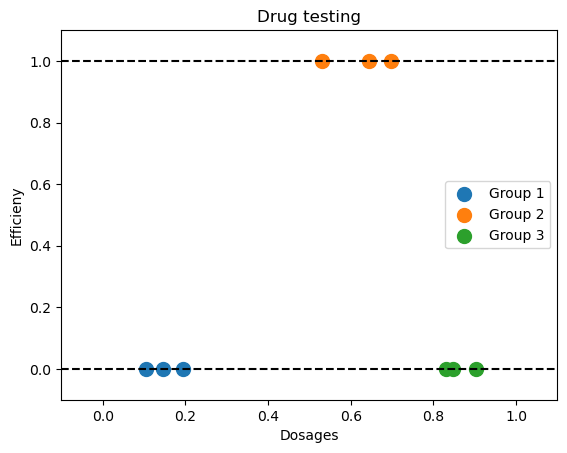

In [47]:
np.random.seed(2228)
group1_dosages = np.random.uniform(0,0.2,3)
group1_efficiency = 3 * [0]
group2_dosages = np.random.uniform(0.25,0.7,3)
group2_efficiency = 3 * [1]
group3_dosages = np.random.uniform(0.75,1,3)
group3_efficiency = 3 * [0]
plt.scatter(group1_dosages,group1_efficiency,s=100,label="Group 1")
plt.scatter(group2_dosages,group2_efficiency,s=100,label="Group 2")
plt.scatter(group3_dosages,group3_efficiency,s=100,label="Group 3")
plt.xlim((-0.1,1.1))
plt.ylim((-0.1,1.1))
plt.xlabel("Dosages")
plt.ylabel("Efficieny")
plt.title("Drug testing")
plt.axhline(1,linestyle="--",c="black")
plt.axhline(0,linestyle="--",c="black")
plt.legend()
plt.show()

## Neural Network

$$
y = W^{(2)} \sigma(W^{(1)}x+b^{(1)})+b^{(3)}
$$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/nn.jpeg" width="550"/>
</div>

- Input: $x \in \mathbb{R}^1$ 
- First weights matrix: $W^{(1)}=\begin{bmatrix} w_{1,1} \\ w_{1,2} \end{bmatrix} \in \mathbb{R}^{2 \times 1}$
- First bias vector: $b^{(1)}=\begin{bmatrix} b_{1} \\ b_{2} \end{bmatrix} \in \mathbb{R}^{2}$

- Second weights matrix: $W^{(2)}=\left[w_{2,1} \quad w_{2,2} \right] \in \mathbb{R}^{1 \times 2}$
- Bias: $b^{(3)} \in \mathbb{R}^1$


### Activation function


<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/Softplus.png" width="550"/>
</div>


### Forward Pass
- $a^{(1)}=W^{(1)}x+b^{(1)}=\begin{bmatrix} w_{1,1}x+b_{1} \\ w_{1,2}x+b_{2} \end{bmatrix} \text{ with } a_{1}^{(1)}=w_{1,1}x+b_{1} \text{ and }a_{2}^{(1)}=w_{1,2}x+b_{2}$

- $z=\sigma(a^{(1)})=\begin{bmatrix} z_{1} \\ z_{2} \end{bmatrix}=\begin{bmatrix} \ln(1+\exp(a_{1}^{(1)})) \\ \ln(1+\exp(a_{2}^{(1)})) \end{bmatrix}$

- $y=W^{(2)}z + b_3=w_{2,1}z_1 + w_{2,2}z_2 + b_3$

- $L=\frac{1}{2}(y-t)^2$


### Backward Pass

$$
\begin{align*}
\frac{\partial L}{\partial b_3}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial b_3}=(y-t)1=y-t \\
\frac{\partial L}{\partial w_{2,1}}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial w_{2,1}}=(y-t)z_1\\
\frac{\partial L}{\partial w_{2,2}}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial w_{2,2}}=(y-t)z_2 \\
\\

\frac{\partial L}{\partial b_1}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial z_1}\frac{\partial z_1}{\partial a_{1}^{(1)}}\frac{\partial a_{1}^{(1)}}{\partial b_1}=(y-t)w_{2,1}\frac{1}{1+\exp(-a_1^{(1)})} \\

\frac{\partial L}{\partial b_2}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial z_2}\frac{\partial z_2}{\partial a_{2}^{(1)}}\frac{\partial a_{2}^{(1)}}{\partial b_2}=(y-t)w_{2,2}\frac{1}{1+\exp(-a_2^{(1)})} \\

\\

\frac{\partial L}{\partial w_{1,1}}&=\frac{\partial L}{\partial y} \frac{\partial y}{\partial z_1}\frac{\partial z_1}{\partial a_{1}^{(1)}}\frac{\partial a_{1}^{(1)}}{\partial w_{1,1}}=(y-t)w_{2,1}\frac{1}{1+\exp(-a_1^{(1)})}x\\

\frac{\partial L}{\partial w_{1,2}}&=\frac{\partial L}{\partial y} \frac{\partial y}{\partial z_2}\frac{\partial z_2}{\partial a_{2}^{(1)}}\frac{\partial a_{2}^{(1)}}{\partial w_{1,2}}=(y-t)w_{2,2}\frac{1}{1+\exp(-a_2^{(1)})}x

\end{align*}
$$

In [48]:
def softplus(x):
    return np.log1p(np.exp(x))


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


class DrugTest:

    def __init__(self, lr=1e-3, epochs=1000, seed=2152):
        np.random.seed(seed)

        # input -> hidden
        self.W1 = np.random.randn(4)
        self.b1 = np.zeros(4)

        # hidden -> output
        self.W2 = np.random.randn(4)
        self.b2 = 0.0

        self.lr = lr
        self.epochs = epochs

    def forward(self, x):
        self.x = x

        self.a1 = self.W1 * x + self.b1
        self.z = softplus(self.a1)

        self.y = self.W2 @ self.z + self.b2

        return self.y

    def backward(self, t):

        # dL/dy
        delta2 = self.y - t

        # output layer gradients
        dW2 = delta2 * self.z
        db2 = delta2 # b_3

        # hidden layer error
        delta1 = delta2* self.W2* sigmoid(self.a1)

        # input layer gradients
        dW1 = delta1 * self.x
        db1 = delta1

        # gradient descent step
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

        return 0.5 * (self.y - t) ** 2

    def train_step(self, x, t):
        y = self.forward(x)
        loss = self.backward(t)
        return y, loss

    def fit(self, X, T):
        losses = []

        for _ in range(self.epochs):
            epoch_loss = 0.0

            for x, t in zip(X, T):
                _, loss = self.train_step(x, t)
                epoch_loss += loss

            losses.append(epoch_loss / len(X))

        return np.array(losses)

    def predict(self, X):
        X = np.asarray(X)
        return np.array([self.forward(x) for x in X])

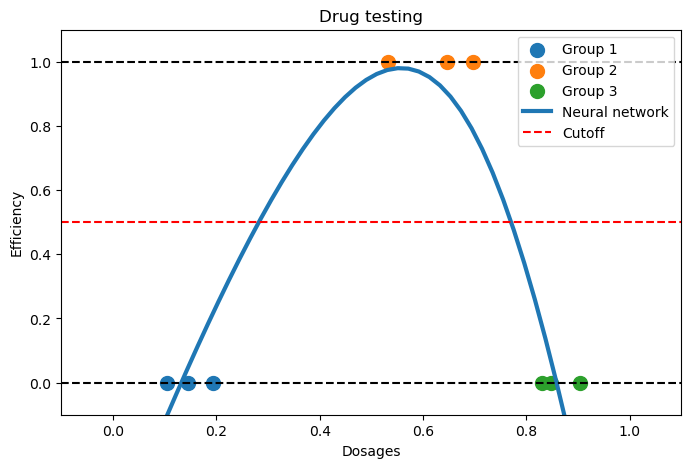

Final loss = 0.018672847437486727
W1 = [-0.71096811 -4.04248125 -0.86538343  8.20857909]
b1 = [-1.55138037  1.96920436 -1.44028066 -5.96909097]
W2 = [ 0.18457195 -1.14870345  0.03348067 -1.20901801]
b2 = 1.863963383775316


In [49]:
X = np.concatenate([group1_dosages,group2_dosages,group3_dosages])
T = np.array(group1_efficiency + group2_efficiency + group3_efficiency)

# Train network
model = DrugTest(lr=0.1,epochs=10000,seed=2227)

losses = model.fit(X, T)


# Evaluate network
x_plot = np.linspace(0, 1, 50)
y_plot = model.predict(x_plot)


# Plot
plt.figure(figsize=(8, 5))

plt.scatter(group1_dosages,group1_efficiency,s=100,label="Group 1")

plt.scatter(group2_dosages,group2_efficiency,s=100,label="Group 2")

plt.scatter(group3_dosages,group3_efficiency,s=100,label="Group 3")

plt.plot(x_plot,y_plot,linewidth=3,label="Neural network")

plt.xlim((-0.1, 1.1))
plt.ylim((-0.1, 1.1))

plt.xlabel("Dosages")
plt.ylabel("Efficiency")
plt.title("Drug testing")

plt.axhline(1, linestyle="--", c="black")
plt.axhline(0, linestyle="--", c="black")
plt.axhline(0.5, linestyle="--", c="red",label="Cutoff")

plt.legend()
plt.show()

print("Final loss =", losses[-1])
print("W1 =", model.W1)
print("b1 =", model.b1)
print("W2 =", model.W2)
print("b2 =", model.b2)

In [50]:
np.random.seed(1328)

group1_dosages = np.random.uniform(0,0.2,3)
group1_efficiency = 3*[0]

group2_dosages = np.random.uniform(0.25,0.7,3)
group2_efficiency = 3*[1]

group3_dosages = np.random.uniform(0.75,1,3)
group3_efficiency = 3*[0]

X = np.concatenate([group1_dosages,group2_dosages,group3_dosages])
print("X=",X,"\n")
y = np.array(group1_efficiency +group2_efficiency +group3_efficiency)
print("y=",y,"\n")

X= [0.07204    0.10213232 0.10098749 0.57997582 0.51934918 0.60193777
 0.95404178 0.96103704 0.76590768] 

y= [0 0 0 1 1 1 0 0 0] 



### PyTorch Implementation

X_torch= tensor([[0.0720],
        [0.1021],
        [0.1010],
        [0.5800],
        [0.5193],
        [0.6019],
        [0.9540],
        [0.9610],
        [0.7659]])
y_torch= tensor([[0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.]])


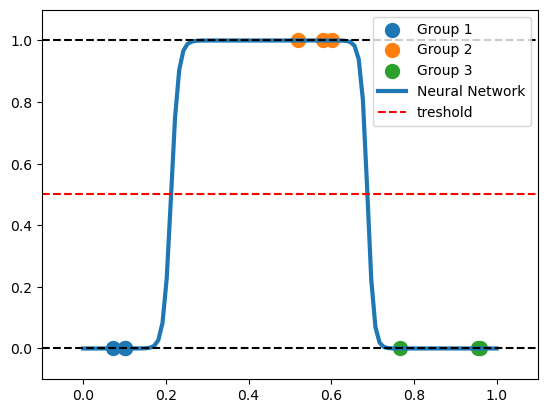

In [51]:
# Convert data to tensors
X_torch = torch.tensor(X.reshape(-1,1),dtype=torch.float32) # reshape X (dosages) to a matrix
print("X_torch=",X_torch)
y_torch = torch.tensor(y.reshape(-1,1),dtype=torch.float32) # reshape y (efficiency) to a matrix
print("y_torch=",y_torch)

torch.manual_seed(2152)

# Define the network
class DrugNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.hidden = nn.Linear(1, 5)
        self.output = nn.Linear(5, 1)

    def forward(self, x):
        # Input (1) -> Dense(5) -> Softplus -> Dense(1) -> Linear output (logit)
        x = F.softplus(self.hidden(x))

        # raw logits
        x = self.output(x)
        return x



# Create model
model = DrugNet()

# Criterion
criterion = nn.BCEWithLogitsLoss()
#criterion = nn.MSELoss()
#criterion = nn.BCELoss()

# Optimizer
optimizer = optim.Adam(model.parameters(),lr=1e-2)

# Training loop
epochs = 10000
losses = []

for epoch in range(epochs):

    optimizer.zero_grad()

    logits = model(X_torch)

    loss = criterion(logits, y_torch)

    loss.backward()

    optimizer.step()

    losses.append(loss.item())
    losses.append(loss.item())

# Predictions
x_plot = np.linspace(0,1,100)

x_test = torch.tensor(x_plot.reshape(-1,1),dtype=torch.float32)


with torch.no_grad():

    logits = model(x_test)

    # convert logits -> probabilities
    y_plot = torch.sigmoid(logits).numpy()

plt.scatter(group1_dosages,group1_efficiency,s=100,label="Group 1")

plt.scatter(group2_dosages,group2_efficiency,s=100,label="Group 2")

plt.scatter(group3_dosages,group3_efficiency,s=100,label="Group 3")

plt.plot(x_plot,y_plot,linewidth=3,label="Neural Network")

plt.xlim((-0.1,1.1))
plt.ylim((-0.1,1.1))
plt.axhline(0, ls="--", c="black")
plt.axhline(1, ls="--", c="black")
plt.axhline(.5, ls="--", c="red",label="treshold")
plt.legend()
plt.show()

### TensorFlow / Keras implementation

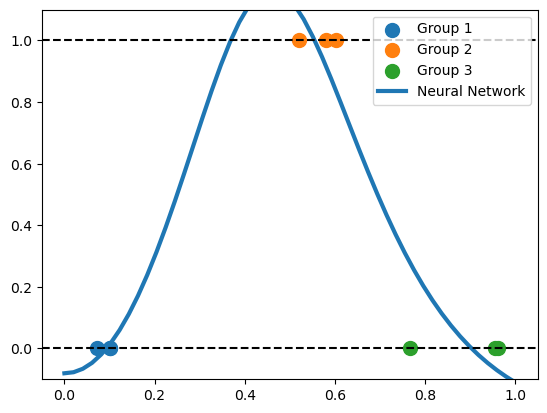

In [52]:
# Set seeds
np.random.seed(1402)
tf.random.set_seed(1402)
keras.utils.set_random_seed(1402)

#keras.utils.set_random_seed(1402) # or just this

# Convert to tensors
X_tf = X.reshape(-1,1).astype(np.float32)
y_tf = y.reshape(-1,1).astype(np.float32)

# Define the model
initializer = keras.initializers.RandomNormal(mean=0.0,stddev=2.0,seed=1402) # to initialize larger weights
model = keras.Sequential([
    keras.Input(shape=(1,)),
    layers.Dense(5, activation="softplus"),
    layers.Dense(1)])

# or equivalently
# model = keras.Sequential()
# model.add(keras.Input(shape=(1,)))
# model.add(layers.Dense(5, activation="softplus"))
# model.add(layers.Dense(1))

# Compile
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-1),loss="mse")
# model.compile(optimizer='adam',loss="mse")

# Train
history = model.fit(X_tf,y_tf,epochs=1000,verbose=0)

# Predict
x_plot = np.linspace(0,1,50).reshape(-1,1)

y_plot = model.predict(x_plot,verbose=0)

plt.scatter(group1_dosages,group1_efficiency,s=100,label="Group 1")

plt.scatter(group2_dosages,group2_efficiency,s=100,label="Group 2")

plt.scatter(group3_dosages,group3_efficiency,s=100,label="Group 3")

plt.plot(x_plot,y_plot,linewidth=3,label="Neural Network")

#plt.xlim((-0.1,1.1))
plt.ylim((-0.1,1.1))
plt.axhline(0, ls="--", c="black")
plt.axhline(1, ls="--", c="black")
plt.legend()
plt.show()

<a class="anchor" id="dim"></a>

# 16. Matrix dimensions of multiple hidden-layer neural networks


<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/90.png" width="550"/>
  <img src="pics/41.png" width="550"/>
</div>




* Input layer: $p=3$ neurons
* Hidden layer 1: $m_1=4$ neurons
* Hidden layer 2: $m_2=4$ neurons
* Hidden layer 3: $m_l=m_3=4$ neurons
* $l=3$ hidden layers
* Output layer: $g=3$ neurons

Usually denote the activations as $$z^{(0)}=x \in \mathbb{R}^p=\mathbb{R}^3$$

>The rule is: If layer $i-1$ has $n_{i-1}$ neurons and layer $i$ has $n_i$ neurons, then $$W^{(i)} \in \mathbb{R}^{n_i \times n_{i-1}}, \quad b^{(i)} \in \mathbb{R}^{n_i} \\ a^{(i)}=W^{(i)}z^{(i-1)} + b^{(i)}, \quad i=1,\ldots,l+1 \\ z^{(i)}=\sigma(a^{(i)}), \quad i=1,\ldots,l \\ y=\tau(a^{(l+1)}) $$

### Layer 1 (Input $\rightarrow$ Hidden 1)

Input: $$x = \begin{bmatrix} x_1 \\ x_2 \\ x_3  \end{bmatrix} \in \mathbb{R}^3$$

Since there are 4 neurons in the first hidden layer, $$W^{(1)} \in \mathbb{R}^{4 \times 3}, \quad b^{(1)}=\begin{bmatrix} b_1^{(1)} \\ b_2^{(1)} \\ b_3^{(1)} \\ b_4^{(1)} \end{bmatrix} \in \mathbb{R}^4$$

Explicitly, 
$$W^{(1)} = 
\begin{bmatrix} 
w_{11}^{(1)} & w_{12}^{(1)} & w_{13}^{(1)} \\ 
w_{21}^{(1)} & w_{22}^{(1)} & w_{23}^{(1)} \\
w_{31}^{(1)} & w_{32}^{(1)} & w_{33}^{(1)} \\
w_{41}^{(1)} & w_{42}^{(1)} & w_{43}^{(1)} 
\end{bmatrix}
$$

$$
\begin{array}{c|ccc}
 & x_1 & x_2 & x_3 \\ \hline
z_{1,1} & w_{11}^{(1)} & w_{12}^{(1)} & w_{13}^{(1)} \\
z_{2,1} & w_{21}^{(1)} & w_{22}^{(1)} & w_{23}^{(1)} \\
z_{3,1} & w_{31}^{(1)} & w_{32}^{(1)} & w_{33}^{(1)} \\
z_{4,1} & w_{41}^{(1)} & w_{42}^{(1)} & w_{43}^{(1)} 
\end{array} \\ 

\text{ Columns } \begin{bmatrix} w_{1r}^{(1)} \\ w_{2r}^{(1)} \\ w_{3r}^{(1)} \\ w_{4r}^{(1)} \end{bmatrix}  \text{ of } W^{(1)}  \text{ contain all weights coming out of input }x_{r} \text{ for }r=1,\ldots,3=p \\

\text{ Rows } \begin{bmatrix} w_{j1}^{(1)} & w_{j2}^{(1)} & w_{j3}^{(1)} \end{bmatrix}  \text{ of } W^{(1)}  \text{ contain all weights feeding into neuron }z_{j,1} \text{ for }j=1,\ldots,4=m_1 \\
$$



The affine transformations are 
$$a^{(1)} = W^{(1)}x + b^{(1)} = 
\begin{bmatrix} 
w_{11}^{(1)}x_1 + w_{12}^{(1)}x_2 + w_{13}^{(1)}x_3 + b_1^{(1)} \\  
w_{21}^{(1)}x_1 + w_{22}^{(1)}x_2 + w_{23}^{(1)}x_3 + b_2^{(1)} \\
w_{31}^{(1)}x_1 + w_{32}^{(1)}x_2 + w_{33}^{(1)}x_3 + b_3^{(1)} \\
w_{41}^{(1)}x_1 + w_{42}^{(1)}x_2 + w_{43}^{(1)}x_3 + b_4^{(1)} 
\end{bmatrix}
=
\begin{bmatrix} 
a_1^{(1)} \\  
a_2^{(1)}  \\
a_3^{(1)}  \\
a_{m_1}^{(1)} 
\end{bmatrix}
 \in \mathbb{R}^4$$

The non-linear activations are 
$$
z^{(1)}=\sigma(a^{(1)})=
\begin{bmatrix} 
\sigma(a_1^{(1)}) \\  
\sigma(a_2^{(1)})  \\
\sigma(a_3^{(1)})  \\
\sigma(a_{m_1}^{(1)}) 
\end{bmatrix}
= 
\begin{bmatrix} 
z_{1,1} \\  
z_{2,1} \\
z_{3,1}  \\
z_{m_1,1}
\end{bmatrix} \in \mathbb{R}^4
$$

---


### Layer 2 (Hidden 1 $\rightarrow$ Hidden 2)

Since there are 4 neurons in the previous hidden layer and 4 neurons in the following hidden layer , $$W^{(2)} \in \mathbb{R}^{4 \times 4}, \quad b^{(2)}=\begin{bmatrix} b_1^{(2)} \\ b_2^{(2)} \\ b_3^{(2)} \\ b_4^{(2)} \end{bmatrix} \in \mathbb{R}^4$$

Explicitly, 
$$W^{(2)} = 
\begin{bmatrix} 
w_{11}^{(2)} & w_{12}^{(2)} & w_{13}^{(2)} & w_{14}^{(2)} \\ 
w_{21}^{(2)} & w_{22}^{(2)} & w_{23}^{(2)} & w_{24}^{(2)} \\
w_{31}^{(2)} & w_{32}^{(2)} & w_{33}^{(2)} & w_{34}^{(2)} \\
w_{41}^{(2)} & w_{42}^{(2)} & w_{43}^{(2)} & w_{44}^{(2)} 
\end{bmatrix}
$$
$$
\begin{array}{c|ccc}
 & z_{1,1} & z_{2,1} & z_{3,1} & z_{m_1,1} \\ \hline
z_{1,2} & w_{11}^{(2)} & w_{12}^{(2)} & w_{13}^{(2)} & w_{14}^{(2)} \\
z_{2,2} & w_{21}^{(2)} & w_{22}^{(2)} & w_{23}^{(2)} & w_{24}^{(2)} \\
z_{3,2} & w_{31}^{(2)} & w_{32}^{(2)} & w_{33}^{(2)} & w_{34}^{(2)} \\
z_{m_2,2} & w_{41}^{(2)} & w_{42}^{(2)} & w_{43}^{(2)} & w_{44}^{(2)}
\end{array} 
\\
\text{ Columns } \begin{bmatrix} w_{1j}^{(2)} \\ w_{2j}^{(2)} \\ w_{3j}^{(2)} \\ w_{4j}^{(2)} \end{bmatrix}  \text{ of } W^{(2)}  \text{ contain all weights coming out of neuron }z_{j,1} \text{ for }j=1,\ldots,4=m_1 \\

\text{ Rows } \begin{bmatrix} w_{j1}^{(2)} & w_{j2}^{(2)} & w_{j3}^{(2)} & w_{j4}^{(2)} \end{bmatrix}  \text{ of } W^{(2)}  \text{ contain all weights feeding into neuron }z_{j,2} \text{ for }j=1,\ldots,4=m_2 \\
$$



The affine transformations are 
$$a^{(2)} = W^{(2)}z^{(1)} + b^{(2)} = 
\begin{bmatrix} 
w_{11}^{(2)}z_{1,1} + w_{12}^{(2)}z_{2,1} + w_{13}^{(2)}z_{3,1} + w_{14}^{(2)}z_{m_1,1} + b_1^{(2)} \\  
w_{21}^{(2)}z_{1,1} + w_{22}^{(2)}z_{2,1} + w_{23}^{(2)}z_{3,1} +  w_{24}^{(2)}z_{m_1,1}+ b_2^{(2)} \\
w_{31}^{(2)}z_{1,1} + w_{32}^{(2)}z_{2,1} + w_{33}^{(2)}z_{3,1} +  w_{34}^{(2)}z_{m_1,1}+ b_3^{(2)} \\
w_{41}^{(2)}z_{1,1} + w_{42}^{(2)}z_{2,1} + w_{43}^{(2)}z_{3,1} +  w_{44}^{(2)}z_{m_1,1}+  b_4^{(2)} 
\end{bmatrix}
=
\begin{bmatrix} 
a_1^{(2)} \\  
a_2^{(2)}  \\
a_3^{(2)}  \\
a_{m_2}^{(2)} 
\end{bmatrix}
 \in \mathbb{R}^4$$

The non-linear activations are 
$$
z^{(2)}=\sigma(a^{(2)})=
\begin{bmatrix} 
\sigma(a_1^{(2)}) \\  
\sigma(a_2^{(2)})  \\
\sigma(a_3^{(2)})  \\
\sigma(a_{m_2}^{(2)}) 
\end{bmatrix}
= 
\begin{bmatrix} 
z_{1,2} \\  
z_{2,2} \\
z_{3,2}  \\
z_{m_2,2}
\end{bmatrix} \in \mathbb{R}^4
$$


---


### Layer 3 (Hidden 2 $\rightarrow$ Hidden 3)

Since there are 4 neurons in the previous hidden layer and 4 neurons in the following hidden layer , $$W^{(3)} \in \mathbb{R}^{4 \times 4}, \quad b^{(3)}=\begin{bmatrix} b_1^{(3)} \\ b_2^{(3)} \\ b_3^{(3)} \\ b_4^{(3)} \end{bmatrix} \in \mathbb{R}^4$$

Explicitly, 
$$W^{(3)} = 
\begin{bmatrix} 
w_{11}^{(3)} & w_{12}^{(3)} & w_{13}^{(3)} & w_{14}^{(3)} \\ 
w_{21}^{(3)} & w_{22}^{(3)} & w_{23}^{(3)} & w_{24}^{(3)} \\
w_{31}^{(3)} & w_{32}^{(3)} & w_{33}^{(3)} & w_{34}^{(3)} \\
w_{41}^{(3)} & w_{42}^{(3)} & w_{43}^{(3)} & w_{44}^{(3)} 
\end{bmatrix}
$$
$$
\begin{array}{c|ccc}
 & z_{1,2} & z_{2,2} & z_{3,2} & z_{m_2,2} \\ \hline
z_{1,3} & w_{11}^{(3)} & w_{12}^{(3)} & w_{13}^{(3)} & w_{14}^{(3)} \\
z_{2,3} & w_{21}^{(3)} & w_{22}^{(3)} & w_{23}^{(3)} & w_{24}^{(3)} \\
z_{3,3} & w_{31}^{(3)} & w_{32}^{(3)} & w_{33}^{(3)} & w_{34}^{(3)} \\
z_{m_3,3} & w_{41}^{(3)} & w_{42}^{(3)} & w_{43}^{(3)} & w_{44}^{(3)}
\end{array} 
\\
\text{ Columns } \begin{bmatrix} w_{1j}^{(3)} \\ w_{2j}^{(3)} \\ w_{3j}^{(3)} \\ w_{4j}^{(3)} \end{bmatrix}  \text{ of } W^{(3)}  \text{ contain all weights coming out of neuron }z_{j,2} \text{ for }j=1,\ldots,4=m_2 \\

\text{ Rows } \begin{bmatrix} w_{j1}^{(3)} & w_{j2}^{(3)} & w_{j3}^{(3)} & w_{j4}^{(3)} \end{bmatrix}  \text{ of } W^{(3)}  \text{ contain all weights feeding into neuron }z_{j,3} \text{ for }j=1,\ldots,4=m_3 \\
$$



The affine transformations are 
$$a^{(3)} = W^{(3)}z^{(2)} + b^{(3)} = 
\begin{bmatrix} 
w_{11}^{(3)}z_{1,2} + w_{12}^{(3)}z_{2,2} + w_{13}^{(3)}z_{3,2} + w_{14}^{(3)}z_{m_2,2} + b_1^{(3)} \\  
w_{21}^{(3)}z_{1,2} + w_{22}^{(3)}z_{2,2} + w_{23}^{(3)}z_{3,2} +  w_{24}^{(3)}z_{m_2,2}+ b_2^{(3)} \\
w_{31}^{(3)}z_{1,2} + w_{32}^{(3)}z_{2,2} + w_{33}^{(3)}z_{3,2} +  w_{34}^{(3)}z_{m_2,2}+ b_3^{(3)} \\
w_{41}^{(3)}z_{1,2} + w_{42}^{(3)}z_{2,2} + w_{43}^{(3)}z_{3,2} +  w_{44}^{(3)}z_{m_2,2}+  b_4^{(3)} 
\end{bmatrix}
=
\begin{bmatrix} 
a_1^{(3)} \\  
a_2^{(3)}  \\
a_3^{(3)}  \\
a_{m_3}^{(3)} 
\end{bmatrix}
 \in \mathbb{R}^4$$

The non-linear activations are 
$$
z^{(3)}=\sigma(a^{(3)})=
\begin{bmatrix} 
\sigma(a_1^{(3)}) \\  
\sigma(a_2^{(3)})  \\
\sigma(a_3^{(3)})  \\
\sigma(a_{m_3}^{(3)}) 
\end{bmatrix}
= 
\begin{bmatrix} 
z_{1,3} \\  
z_{2,3} \\
z_{3,3}  \\
z_{m_3,3}
\end{bmatrix} \in \mathbb{R}^4
$$


---


### Layer 4 (Hidden 3 $\rightarrow$ Output)

Since there are 4 neurons in the previous hidden layer and 3 neurons in the output layer , $$W^{(4)} \in \mathbb{R}^{3 \times 4}, \quad b^{(4)}=\begin{bmatrix} b_1^{(4)} \\ b_2^{(4)} \\ b_3^{(4)}  \end{bmatrix} \in \mathbb{R}^3$$

Explicitly, 
$$W^{(4)} = 
\begin{bmatrix} 
w_{11}^{(4)} & w_{12}^{(4)} & w_{13}^{(4)} & w_{14}^{(4)} \\ 
w_{21}^{(4)} & w_{22}^{(4)} & w_{23}^{(4)} & w_{24}^{(4)} \\
w_{31}^{(4)} & w_{32}^{(4)} & w_{33}^{(4)} & w_{34}^{(4)} \\
\end{bmatrix}
$$
$$
\begin{array}{c|ccc}
 & z_{1,3} & z_{2,3} & z_{3,3} & z_{m_3,3} \\ \hline
f_{1} & w_{11}^{(4)} & w_{12}^{(4)} & w_{13}^{(4)} & w_{14}^{(4)} \\
f_{2} & w_{21}^{(4)} & w_{22}^{(4)} & w_{23}^{(4)} & w_{24}^{(4)} \\
f_{g} & w_{31}^{(4)} & w_{32}^{(4)} & w_{33}^{(4)} & w_{34}^{(4)}
\end{array} 
\\
\text{ Columns } \begin{bmatrix} w_{1j}^{(4)} \\ w_{2j}^{(4)} \\ w_{3j}^{(4)} \end{bmatrix}  \text{ of } W^{(4)}  \text{ contain all weights coming out of neuron }z_{j,3} \text{ for }j=1,\ldots,4=m_3 \\

\text{ Rows } \begin{bmatrix} w_{r1}^{(4)} & w_{r2}^{(4)} & w_{r3}^{(4)} & w_{r4}^{(4)} \end{bmatrix}  \text{ of } W^{(4)}  \text{ contain all weights feeding into output neuron }f_{r} \text{ for }r=1,\ldots,3=g \\
$$



The affine transformations are 
$$a^{(4)} = W^{(4)}z^{(3)} + b^{(4)} = 
\begin{bmatrix} 
w_{11}^{(4)}z_{1,3} + w_{12}^{(4)}z_{2,3} + w_{13}^{(4)}z_{3,3} + w_{14}^{(4)}z_{m_3,3} + b_1^{(4)} \\  
w_{21}^{(4)}z_{1,3} + w_{22}^{(4)}z_{2,3} + w_{23}^{(4)}z_{3,3} +  w_{24}^{(4)}z_{m_3,3}+ b_2^{(4)} \\
w_{31}^{(4)}z_{1,3} + w_{32}^{(4)}z_{2,3} + w_{33}^{(4)}z_{3,3} +  w_{34}^{(4)}z_{m_3,3}+ b_3^{(4)} \\
\end{bmatrix}
=
\begin{bmatrix} 
a_1^{(4)} \\  
a_2^{(4)}  \\
a_3^{(4)}  \\
\end{bmatrix}
 \in \mathbb{R}^3$$

The non-linear activations are 
$$
y=\tau(a^{(4)})=
\begin{bmatrix} 
\tau(a_1^{(4)}) \\  
\tau(a_2^{(4)})  \\
\tau(a_3^{(4)})  \\
\end{bmatrix}
= 
\begin{bmatrix} 
y_1 \\  
y_2 \\
y_3  \\
\end{bmatrix} \in \mathbb{R}^3
$$

In general

- hidden layers:
$$
z^{(l)} = \sigma(a^{(l)})
$$

- output layer:
$$
y = \tau(a^{(l+1)})
$$

where $\tau$ may or may not equal $\sigma$

Examples:

- Regression $$\tau(x)=x$$
- Binary classification: $$\tau(x)=\text{sigmoid}(x)$$
- Multi-class classification: $$\tau(x)=\text{softmax}(x)$$



>So every weight matrix has shape $$\text{(number of neurons in current layer)} \times \text{(number of neurons in previous layer)}$$
>Rows = weights feeding into the neurons in the current layer <br>
>Columns = weights coming out of the neurons in the previous layer

<a class="anchor" id="example7"></a>

# 17. Example 7

We want to classify a flower based on their Petal and Sepal Width as Setosa, Versicolor or Virginica.

$$
y = \text{softmax}(W^{(2)}\text{ReLU}(W^{(1)}x + b^{(1)}) + b^{(2)})
$$

- Choose as activation function $\sigma(x)=\text{ReLU}(x)=\max(0,x)=\begin{cases} 0, & x < 0 \\ x, & x \geq 0  \end{cases} $
- Choose as final evaluation function $\tau(z_i)=\text{softmax}(z_i)=\frac{\exp(z_i)}{\sum_{j=1}^n \exp(z_j)}$ for $i=1,\ldots,n$ given input vector $z=(z_1,z_2,\ldots,z_n)$
  - $0 \leq \text{softmax}(z_i) \leq 1$
  - $\sum_{i=1}^n \text{softmax}(z_i)=1$
  - Example: For $z=[2,1,0] \rightarrow \text{softmax}(z)=\left[\frac{\exp(2)}{\exp(2)+\exp(1)+\exp(0)},\frac{\exp(1)}{\exp(2)+\exp(1)+\exp(0)},\frac{\exp(0)}{\exp(2)+\exp(1)+\exp(0)}\right]$, these outputs can be interpreted as class probabilities

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/91.jpg" width="550"/>
</div>

- $W^{(1)}=\begin{bmatrix} w_{1,1}^{(1)} & w_{2,1}^{(1)} \\ w_{1,2}^{(1)} & w_{2,2}^{(1)} \end{bmatrix} \in \mathbb{R}^{2 \times 2}$
- $b^{(1)}=\begin{bmatrix} b_1^{(1)} \\ b_2^{(1)} \end{bmatrix} \in \mathbb{R}^{2}$

- $W^{(2)}=\begin{bmatrix} w_{1,1}^{(2)} & w_{2,1}^{(2)} \\ w_{1,2}^{(2)} & w_{2,2}^{(2)} \\ w_{1,3}^{(2)} & w_{2,3}^{(2)} \end{bmatrix} \in \mathbb{R}^{3 \times 2}$
- $b^{(2)}=\begin{bmatrix} b_1^{(2)} \\ b_2^{(2)} \\ b_3^{(2)} \end{bmatrix} \in \mathbb{R}^{3}$

### Forward pass
- $z^{(0)}=x = \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} \in \mathbb{R}^2$
- $a^{(1)} = W^{(1)}z^{(0)} + b^{(1)} \in \mathbb{R}^2$
- $z^{(1)}=\sigma(a^{(1)})  \in \mathbb{R}^2$
- $a^{(2)} = W^{(2)} z^{(1)} + b^{(2)} \in \mathbb{R}^3$
- $y = \tau(a^{(2)})=\begin{bmatrix} f_1 \\ f_2\\ f_3 \end{bmatrix} \in \mathbb{R}^{3}$, where $f_k$ is the predicted probability of class $k \in \{1,2,3\}$
- Categorical cross-entropy $L(y,t)=-\sum_{i=1}^3 t_i \log(f_i)$ with $y_i=f_i$
  - Suppose the true flower is Setosa: $t=\begin{bmatrix} t_1 \\ t_2\\ t_3 \end{bmatrix}=\begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}$
  $\left(\text{Versicolor}=\begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix},\text{Virginica}=\begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}\right)$ and the network predicts $y=\begin{bmatrix} 0.8 \\ 0.1 \\ 0.1 \end{bmatrix}$

  - $L(y,t)=-(1 \cdot \log(0.8)+0 \cdot \log(0.1)+0 \cdot \log(0.1)) \approx 0.223$ small loss because the correct class received high probability

  - Usually we average over the dataset $L=-\frac{1}{N}\sum_{k=1}^N \sum_{i=1}^3 t_i^{(k)} \log\left(f_i^{(k)}\right)$ with $y_i^{(k)}=f_i^{(k)}$ and this is the loss typically minimized during training


### Backward pass

$$
\begin{align*}
\frac{\partial L}{\partial b^{(2)}}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial a^{(2)}}\frac{\partial a^{(2)}}{\partial b^{(2)}}= \ldots \\



\frac{\partial L}{\partial W^{(2)}}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial a^{(2)}}\frac{\partial a^{(2)}}{\partial W^{(2)}}=\ldots \\


\frac{\partial L}{\partial b^{(1)}}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial a^{(2)}}\frac{\partial a^{(2)}}{\partial z^{(1)}}\frac{\partial z^{(1)}}{\partial a^{(1)}}\frac{\partial a^{(1)}}{\partial b^{(1)}}=\ldots \\



\frac{\partial L}{\partial W^{(1)}}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial a^{(2)}}\frac{\partial a^{(2)}}{\partial z^{(1)}}\frac{\partial z^{(1)}}{\partial a^{(1)}}\frac{\partial a^{(1)}}{\partial W^{(1)}}=\ldots \\

\end{align*}
$$

$$
\frac{\partial L}{\partial y}=\begin{bmatrix} -t_1/y_1 \\ -t_2/y_2 \\ -t_3/y_3 \end{bmatrix}
$$

$$
\begin{align*}
\frac{\partial y_i}{\partial a_j^{(2)}}&=\frac{\partial}{\partial a_j^{(2)}}\tau(a_j^{(2)})\\
&=\frac{\partial}{\partial a_j^{(2)}}\frac{\exp(a_i^{(2)})}{\sum_{k=1}^3 \exp(a_k^{(2)})} \quad \mid S=\sum_{k=1}^3 \exp(a_k^{(2)})  \\
&= \frac{\frac{\partial}{\partial a_j^{(2)}} \exp(a_i^{(2)}) \cdot S -  \exp(a_i^{(2)})  \frac{\partial}{\partial a_j^{(2)}} S}{S^2} \quad \mid \frac{\partial}{\partial a_j^{(2)}} \exp(a_i^{(2)})=\delta_{ij}\exp(a_i^{(2)}) \text{ with } \delta_{ij}=\begin{cases} 1, &i=j \\ 0, &i \neq j \end{cases} \\
&= \frac{\delta_{ij}\exp(a_i^{(2)}) \cdot S -  \exp(a_i^{(2)})  \frac{\partial}{\partial a_j^{(2)}} S}{S^2} \quad \mid \frac{\partial}{\partial a_j^{(2)}} S = \exp(a_j^{(2)}) \\
&= \frac{\delta_{ij}\exp(a_i^{(2)}) \cdot S -  \exp(a_i^{(2)}) \exp(a_j^{(2)})}{S^2} \quad \mid y_i=\frac{\exp(a_i^{(2)})}{S},y_j=\frac{\exp(a_j^{(2)})}{S} \\
&= y_i(\delta_{ij}-y_j) \\
&= \begin{cases} y_i(1-y_j), &i=j \\ -y_iy_j, &i \neq j \end{cases} \\
\Rightarrow 
\frac{\partial y}{\partial a^{(2)}}&= 
\begin{bmatrix} 
y_1(1-y_1) & -y_1y_2 & -y_1y_3 \\   
-y_2y_1 & y_2(1-y_2) & -y_2y_3 \\   
-y_3y_1 & -y_3y_2 & y_3(1-y_3)
\end{bmatrix}
\end{align*}
$$


$$
\frac{\partial a^{(2)}}{\partial b^{(2)}} = \mathrm{I}_3 =  \begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}
$$


$$
\frac{\partial a^{(2)}}{\partial W^{(2)}}=z^{(1)}
$$

$$
\frac{\partial a^{(2)}}{\partial z^{(1)}}=W^{(2)}
$$


$$
\begin{align*}
\frac{\partial z_i^{(1)}}{\partial a_i^{(1)}}
&=\frac{\partial}{\partial a_i^{(1)}} \sigma(a_i^{(1)}) \\
&= \begin{cases} 1, &a_i^{(1)}>0 \\ 0, &a_i^{(1)}<0 \end{cases}\\
&=\frac{\partial}{\partial a_i^{(1)}}\text{ReLU}(a_i^{(1)}) \\
\Rightarrow \frac{\partial z^{(1)}}{\partial a^{(1)}}&=\text{Diag}(\frac{\partial}{\partial a_1^{(1)}}\text{ReLU}(a_1^{(1)}),\frac{\partial}{\partial a_2^{(1)}}\text{ReLU}(a_2^{(1)}))

\end{align*}
$$

$$
\frac{\partial a^{(1)}}{\partial b^{(1)}} = \mathrm{I}_2 = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}
$$

$$
\frac{\partial a^{(1)}}{\partial W^{(1)}}= z^{(0)}=x
$$



$$
\begin{align*}
\frac{\partial L}{\partial b^{(2)}}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial a^{(2)}}\frac{\partial a^{(2)}}{\partial b^{(2)}}= \sum_{i=1}^3 \left(-\frac{t_i}{y_i}\right)y_i(\delta_{ij}-y_j) \cdot 1 = - \sum_{i=1}^3 t_i(\delta_{ij}-y_j)=-t_j + y_j \underbrace{\sum_{i=1}^3 t_i}_{=1} = y - t = \begin{bmatrix} y_1-t_1 \\ y_2-t_2 \\ y_3-t_3  \end{bmatrix} \in \mathbb{R}^3\\



\frac{\partial L}{\partial W^{(2)}}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial a^{(2)}}\frac{\partial a^{(2)}}{\partial W^{(2)}}=(y-t)(z^{(1)})^\top = \begin{bmatrix} y_1-t_1 \\ y_2-t_2 \\ y_3-t_3  \end{bmatrix} \begin{bmatrix} z_1^{(1)} & z_2^{(1)}  \end{bmatrix} \in \mathbb{R}^{3 \times 2} \\


\frac{\partial L}{\partial b^{(1)}}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial a^{(2)}}\frac{\partial a^{(2)}}{\partial z^{(1)}}\frac{\partial z^{(1)}}{\partial a^{(1)}}\frac{\partial a^{(1)}}{\partial b^{(1)}}=(y-t)W^{(2)}\text{Diag}(\frac{\partial}{\partial a_1^{(1)}}\text{ReLU}(a_1^{(1)}),\frac{\partial}{\partial a_2^{(1)}}\text{ReLU}(a_2^{(1)})) \cdot 1 = ((W^{(2)})^\top(y-t)) \begin{bmatrix} 1_{a_1^{(1)}>0} \\ 1_{a_2^{(1)}>0} \end{bmatrix} \in \mathbb{R}^2 \\



\frac{\partial L}{\partial W^{(1)}}&=\frac{\partial L}{\partial y}\frac{\partial y}{\partial a^{(2)}}\frac{\partial a^{(2)}}{\partial z^{(1)}}\frac{\partial z^{(1)}}{\partial a^{(1)}}\frac{\partial a^{(1)}}{\partial W^{(1)}}=(y-t)W^{(2)}\begin{bmatrix} 1_{a_1^{(1)}>0} \\ 1_{a_2^{(1)}>0} \end{bmatrix}z^{(0)}=\left[((W^{(2)})^\top(y-t))\begin{bmatrix} 1_{a_1^{(1)}>0} \\ 1_{a_2^{(1)}>0} \end{bmatrix}\right]x^\top \in \mathbb{R}^{2 \times 2}  \\

\end{align*}
$$

In [71]:
np.random.seed(1705)

# Example input and one-hot target
x = np.array([1.0, 2.0]) # shape (2,)
t = np.array([1.0, 0.0, 0.0]) # shape (3,)

# Initialize parameters
W1 = np.random.randn(2, 2)
b1 = np.zeros(2)
W2 = np.random.randn(3, 2)
b2 = np.zeros(3)

def softmax(x):
    x = x - np.max(x) # numerical stability
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

# Forward pass
def forward(x, t):
    a1 = W1 @ x + b1 # (2,)
    z1 = np.maximum(0, a1) # ReLU

    a2 = W2 @ z1 + b2 # (3,)
    y = softmax(a2)

    L = -np.sum(t * np.log(y + 1e-12)) # avoid logarithm of 0

    return a1, z1, a2, y, L

# Backpropagation + Gradient Descent
def backward(x, t, lr=0.01):
    global W1, b1, W2, b2 # assignements inside this function modify the global variables W1, b1, W2, b2 instead of creating local variables

    a1, z1, a2, y, L = forward(x, t)

    # Output layer
    delta2 = y - t # (3,)

    dLdb2 = delta2 # (3,)
    dLdW2 = np.outer(delta2, z1) # (3,2)

    # Hidden layer
    relu_grad = (a1 > 0).astype(float) # (2,)

    delta1 = (W2.T @ delta2) * relu_grad # (2,)

    dLdb1 = delta1 # (2,)
    dLdW1 = np.outer(delta1, x) # (2,2)

    # Gradient descent update
    b1 -= lr * dLdb1
    W1 -= lr * dLdW1

    b2 -= lr * dLdb2
    W2 -= lr * dLdW2

    return L

# Training
epochs = 1000

for epoch in range(epochs):

    loss = backward(x, t)

    if epoch % 100 == 0:
        print(f"epoch={epoch:4d}, loss={loss:.6f}")

# Final prediction
_, _, _, y, L = forward(x, t)

print("\nFinal prediction:", y)
print("Target:", t)

epoch=   0, loss=1.170513
epoch= 100, loss=0.594512
epoch= 200, loss=0.359745
epoch= 300, loss=0.238143
epoch= 400, loss=0.168124
epoch= 500, loss=0.124065
epoch= 600, loss=0.094463
epoch= 700, loss=0.073618
epoch= 800, loss=0.058442
epoch= 900, loss=0.047122

Final prediction: [0.96220816 0.03456915 0.00322269]
Target: [1. 0. 0.]


In [88]:
np.random.seed(1705)

# 50 observations, 2 features each
X = np.random.randn(50, 2) # shape (50,2)
print("X=\n",X[1:6,:],"\n")

# Random one-hot targets
classes = np.random.randint(0, 3, size=50) # 50 random integers between 0 and 3
T = np.eye(3)[classes] # shape (50,3)
print("T=\n",T[1:6,:],"\n")

# Initialize parameters
W1 = np.random.randn(2, 2)
b1 = np.zeros(2)

W2 = np.random.randn(3, 2)
b2 = np.zeros(3)

def softmax(x):
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

def forward(x, t):

    a1 = W1 @ x + b1
    z1 = np.maximum(0, a1)

    a2 = W2 @ z1 + b2
    y = softmax(a2)

    L = -np.sum(t * np.log(y + 1e-12))

    return a1, z1, a2, y, L

def backward(x, t, lr=0.01):

    global W1, b1, W2, b2

    a1, z1, a2, y, L = forward(x, t)

    delta2 = y - t

    dLdb2 = delta2
    dLdW2 = np.outer(delta2, z1)

    relu_grad = (a1 > 0).astype(float)

    delta1 = (W2.T @ delta2) * relu_grad

    dLdb1 = delta1
    dLdW1 = np.outer(delta1, x)

    W1 -= lr * dLdW1
    b1 -= lr * dLdb1

    W2 -= lr * dLdW2
    b2 -= lr * dLdb2

    return L

# Training
epochs = 1000

for epoch in range(epochs):

    total_loss = 0

    for x, t in zip(X, T):
        total_loss += backward(x, t)

    avg_loss = total_loss / len(X)

    if epoch % 100 == 0:
        print(f"epoch={epoch:4d}, loss={avg_loss:.6f}")

# Final prediction
_, _, _, y, L = forward(X[0,:], T[0,:])

print("\nFinal prediction:", y)
print("Target:", T[0,:])

X=
 [[-1.01472383 -1.293192  ]
 [-0.1628083  -1.26154439]
 [ 1.11601984 -1.46819296]
 [-2.01968923 -0.58673617]
 [-0.32990325  0.26010108]] 

T=
 [[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]] 

epoch=   0, loss=1.250360
epoch= 100, loss=1.074858
epoch= 200, loss=1.064149
epoch= 300, loss=1.052596
epoch= 400, loss=1.047815
epoch= 500, loss=1.046897
epoch= 600, loss=1.045458
epoch= 700, loss=1.044082
epoch= 800, loss=1.044982
epoch= 900, loss=1.043030

Final prediction: [0.43377295 0.22523784 0.34098921]
Target: [0. 0. 1.]


In [91]:
# Load Iris dataset
iris = load_iris()

# Inputs: Sepal Width and Petal Width
X = iris.data[:, [1, 3]]

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Labels (0=Setosa, 1=Versicolor, 2=Virginica)
y = iris.target

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

print("\nClass names:")
print(iris.target_names)

# One-hot encoding
T = np.eye(3)[y]


# Train/Test Split
X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(X,T,y,test_size=0.2,random_state=1705)


# Initialize Parameters
np.random.seed(1705)

W1 = np.random.randn(2, 2)
b1 = np.zeros(2)

W2 = np.random.randn(3, 2)
b2 = np.zeros(3)


# Helper Functions
def softmax(x):
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)


# Forward Pass
def forward(x, t):

    a1 = W1 @ x + b1
    z1 = np.maximum(0, a1)

    a2 = W2 @ z1 + b2
    y = softmax(a2)

    L = -np.sum(t * np.log(y + 1e-12))

    return a1, z1, a2, y, L


# Backpropagation
def backward(x, t, lr=0.01):

    global W1, b1, W2, b2

    a1, z1, a2, y, L = forward(x, t)

    # Output layer
    delta2 = y - t

    dLdb2 = delta2
    dLdW2 = np.outer(delta2, z1)

    # Hidden layer
    relu_grad = (a1 > 0).astype(float)

    delta1 = (W2.T @ delta2) * relu_grad

    dLdb1 = delta1
    dLdW1 = np.outer(delta1, x)

    # Gradient descent update
    W1 -= lr * dLdW1
    b1 -= lr * dLdb1

    W2 -= lr * dLdW2
    b2 -= lr * dLdb2

    return L


# Prediction Function
def predict(x):

    a1 = W1 @ x + b1
    z1 = np.maximum(0, a1)

    a2 = W2 @ z1 + b2
    y = softmax(a2)

    return np.argmax(y)

# Training
epochs = 1000

for epoch in range(epochs):

    total_loss = 0

    for x, t in zip(X_train, T_train):
        total_loss += backward(x, t)

    avg_loss = total_loss / len(X_train)

    if epoch % 100 == 0:
        print(f"epoch={epoch:4d}, loss={avg_loss:.6f}")


# Test Accuracy
correct = 0

for x, label in zip(X_test, y_test):

    pred = predict(x)

    if pred == label:
        correct += 1

accuracy = correct / len(X_test)

print(f"\nTest Accuracy: {accuracy:.4f}")


# Example Prediction
x = X_test[0]

pred = predict(x)

print("\nPrediction:", iris.target_names[pred])
print("Actual:    ", iris.target_names[y_test[0]])


# Network Output Probabilities
_, _, _, y_pred, _ = forward(X_test[0], T_test[0])

print("\nProbabilities:", y_pred)
print("One-hot target:", T_test[0])

Shape of X: (150, 2)
Shape of y: (150,)

Class names:
['setosa' 'versicolor' 'virginica']
epoch=   0, loss=1.216314
epoch= 100, loss=0.086780
epoch= 200, loss=0.080018
epoch= 300, loss=0.078153
epoch= 400, loss=0.077229
epoch= 500, loss=0.076618
epoch= 600, loss=0.076189
epoch= 700, loss=0.075856
epoch= 800, loss=0.075595
epoch= 900, loss=0.075372

Test Accuracy: 0.8667

Prediction: virginica
Actual:     virginica

Probabilities: [0.001075   0.04032375 0.95860125]
One-hot target: [0. 0. 1.]


<a class="anchor" id="library1"></a>

# 18.1 Neural Networks for Regression library

### from scikit-learn

```python
# 1. Neural Network Regressor (scikit-learn)
from sklearn.neural_network import MLPRegressor


# Basic Neural Network for Regression
model1 = MLPRegressor(
    hidden_layer_sizes=(100,),  # one hidden layer with 100 neurons
    activation="relu",          # "identity", "logistic", "tanh", "relu"
    solver="adam",              # "adam", "sgd", "lbfgs"
    alpha=0.0001,               # L2 regularization strength
    batch_size="auto",
    learning_rate="constant",   # "constant", "invscaling", "adaptive"
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

model1.fit(X, y)

model1.predict(X)      # predicted values
model1.score(X, y)     # R^2 score


# Learned Parameters
model1.coefs_          # weight matrices
model1.intercepts_     # bias vectors
model1.n_layers_       # total number of layers
model1.n_outputs_      # number of outputs
model1.loss_           # final training loss
model1.loss_curve_     # loss at each epoch



# 2. Neural Network with Multiple Hidden Layers
deep_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

deep_model.fit(X, y)

deep_model.predict(X)



# 3. Neural Network with Cross-Validation (Grid Search)
from sklearn.model_selection import GridSearchCV

param_grid = {
    "hidden_layer_sizes": [
        (50,),
        (100,),
        (100, 50),
        (128, 64, 32)
    ],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01]
}

model2 = GridSearchCV(
    estimator=MLPRegressor(
        max_iter=1000,
        random_state=42
    ),
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

model2.fit(X, y)

model2.best_params_
model2.best_score_
model2.best_estimator_



# 4. Feature Scaling (Highly Recommended)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation="relu",
        max_iter=1000,
        random_state=42
    ))
])

pipeline.fit(X, y)

pipeline.predict(X)
pipeline.score(X, y)



# 5. Train/Test Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model3 = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

model3.fit(X_train, y_train)

y_pred = model3.predict(X_test)

mean_squared_error(y_test, y_pred)
mean_absolute_error(y_test, y_pred)
r2_score(y_test, y_pred)



# 6. Early Stopping
model4 = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation="relu",
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    max_iter=1000,
    random_state=42
)

model4.fit(X_train, y_train)

model4.best_validation_score_
model4.validation_scores_



# 7. Monitoring Training
import matplotlib.pyplot as plt

model5 = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    max_iter=1000,
    random_state=42
)

model5.fit(X_train, y_train)

plt.plot(model5.loss_curve_)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()



# 8. Manual Architecture Variations

# Small network
small_nn = MLPRegressor(
    hidden_layer_sizes=(16,),
    max_iter=1000
)

# Medium network
medium_nn = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=1000
)

# Deep network
deep_nn = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64, 32),
    max_iter=1000
)



# 9. Extracting Network Structure
nn = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    max_iter=1000,
    random_state=42
)

nn.fit(X, y)

for i, W in enumerate(nn.coefs_):
    print(f"Layer {i}: weights shape = {W.shape}")

for i, b in enumerate(nn.intercepts_):
    print(f"Layer {i}: bias shape = {b.shape}")



# 10. Common Activation Functions

# ReLU
MLPRegressor(activation="relu")

# Hyperbolic tangent
MLPRegressor(activation="tanh")

# Logistic sigmoid
MLPRegressor(activation="logistic")

# Linear activation
MLPRegressor(activation="identity")



# 11. Common Solvers

# Adam (recommended)
MLPRegressor(solver="adam")

# SGD
MLPRegressor(
    solver="sgd",
    learning_rate="adaptive"
)

# L-BFGS
MLPRegressor(solver="lbfgs")



# 12. Prediction on New Data
X_new = X.iloc[:5]  # example

y_new_pred = model1.predict(X_new)



# 13. Important Notes
# - Always scale input features
# - MLPRegressor uses backpropagation + gradient descent
# - hidden_layer_sizes controls model capacity
# - More layers/neurons can model more complex functions
# - ReLU is usually the default choice
# - Adam is usually the best optimizer to start with
# - alpha controls L2 regularization
# - early_stopping can reduce overfitting
# - Monitor loss_curve_ to detect convergence issues
# - Neural networks often require hyperparameter tuning


```

$$
y = W^{(2)} \sigma(W^{(1)}x+b^{(1)})+b^{(3)}
$$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/nn.jpeg" width="550"/>
</div>

W1= [[-0.04328408 -0.72788401]]  of shape  (1, 2)
b1= [-1.09981491  0.86536727]  of shape  (2,)
W2=
 [[-0.24943136]
 [-0.58278914]]  of shape  (2, 1)
b2= [0.61230007]  of shape  (1,)


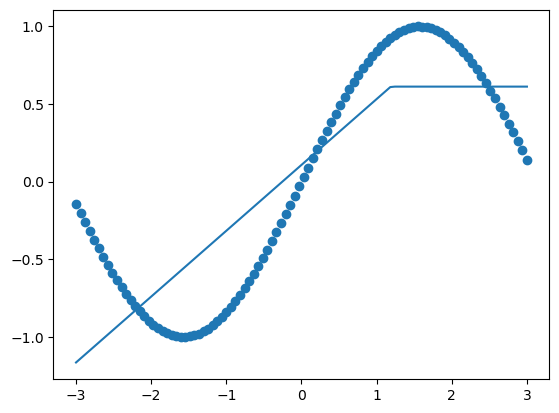

In [100]:
# Training data
np.random.seed(1705)

X = np.linspace(-3, 3, 100).reshape(-1,1)

y = np.sin(X).ravel()


# Neural network
nn = MLPRegressor(
    hidden_layer_sizes=(2,),  # 2 hidden neurons
    activation='relu',
    solver='sgd',
    learning_rate_init=0.01,
    max_iter=5000,
    random_state=1705)

# Training
nn.fit(X, y)

# Predictions
y_pred = nn.predict(X)

# First layer
print("W1=",nn.coefs_[0], " of shape ", nn.coefs_[0].shape)

# First bias
print("b1=",nn.intercepts_[0], " of shape ", nn.intercepts_[0].shape)

# Second layer
print("W2=\n",nn.coefs_[1], " of shape ", nn.coefs_[1].shape)

# Output bias
print("b2=",nn.intercepts_[1], " of shape ", nn.intercepts_[1].shape)


# Plot
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.show()

<a class="anchor" id="library2"></a>

# 18.2 Neural Networks for Classification library

### from scikit-learn

```python
# 1. Neural Network Classifier (scikit-learn)
from sklearn.neural_network import MLPClassifier


# Basic Neural Network for Classification
model1 = MLPClassifier(
    hidden_layer_sizes=(100,),  # one hidden layer with 100 neurons
    activation="relu",          # "identity", "logistic", "tanh", "relu"
    solver="adam",              # "adam", "sgd", "lbfgs"
    alpha=0.0001,               # L2 regularization strength
    batch_size="auto",
    learning_rate="constant",   # "constant", "invscaling", "adaptive"
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

model1.fit(X, y)

model1.predict(X)        # predicted classes
model1.predict_proba(X)  # predicted probabilities
model1.score(X, y)       # accuracy score


# Learned Parameters
model1.coefs_            # weight matrices
model1.intercepts_       # bias vectors
model1.n_layers_         # total number of layers
model1.n_outputs_        # number of outputs
model1.loss_             # final training loss
model1.loss_curve_       # loss at each epoch
model1.classes_          # class labels
model1.out_activation_   # output activation function



# 2. Neural Network with Multiple Hidden Layers
deep_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

deep_model.fit(X, y)

deep_model.predict(X)
deep_model.predict_proba(X)



# 3. Neural Network with Cross-Validation (Grid Search)
from sklearn.model_selection import GridSearchCV

param_grid = {
    "hidden_layer_sizes": [
        (50,),
        (100,),
        (100, 50),
        (128, 64, 32)
    ],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01]
}

model2 = GridSearchCV(
    estimator=MLPClassifier(
        max_iter=1000,
        random_state=42
    ),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

model2.fit(X, y)

model2.best_params_
model2.best_score_
model2.best_estimator_



# 4. Feature Scaling (Highly Recommended)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("nn", MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation="relu",
        max_iter=1000,
        random_state=42
    ))
])

pipeline.fit(X, y)

pipeline.predict(X)
pipeline.predict_proba(X)
pipeline.score(X, y)



# 5. Train/Test Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model3 = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

model3.fit(X_train, y_train)

y_pred = model3.predict(X_test)

accuracy_score(y_test, y_pred)
precision_score(y_test, y_pred, average="weighted")
recall_score(y_test, y_pred, average="weighted")
f1_score(y_test, y_pred, average="weighted")

confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))



# 6. Early Stopping
model4 = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation="relu",
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    max_iter=1000,
    random_state=42
)

model4.fit(X_train, y_train)

model4.best_validation_score_
model4.validation_scores_



# 7. Monitoring Training
import matplotlib.pyplot as plt

model5 = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=1000,
    random_state=42
)

model5.fit(X_train, y_train)

plt.plot(model5.loss_curve_)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()



# 8. Manual Architecture Variations

# Small network
small_nn = MLPClassifier(
    hidden_layer_sizes=(16,),
    max_iter=1000
)

# Medium network
medium_nn = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=1000
)

# Deep network
deep_nn = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32),
    max_iter=1000
)



# 9. Extracting Network Structure
nn = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=1000,
    random_state=42
)

nn.fit(X, y)

for i, W in enumerate(nn.coefs_):
    print(f"Layer {i}: weights shape = {W.shape}")

for i, b in enumerate(nn.intercepts_):
    print(f"Layer {i}: bias shape = {b.shape}")



# 10. Common Activation Functions

# ReLU
MLPClassifier(activation="relu")

# Hyperbolic tangent
MLPClassifier(activation="tanh")

# Logistic sigmoid
MLPClassifier(activation="logistic")

# Linear activation
MLPClassifier(activation="identity")



# 11. Common Solvers

# Adam (recommended)
MLPClassifier(solver="adam")

# SGD
MLPClassifier(
    solver="sgd",
    learning_rate="adaptive"
)

# L-BFGS
MLPClassifier(solver="lbfgs")



# 12. Prediction on New Data
X_new = X.iloc[:5]  # example

y_new_pred = model1.predict(X_new)
y_new_prob = model1.predict_proba(X_new)



# 13. Binary Classification Thresholding
y_prob = model1.predict_proba(X_test)[:, 1]

# Custom threshold instead of 0.5
y_pred_custom = (y_prob >= 0.7).astype(int)



# 14. Multi-Class Classification
multiclass_nn = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=1000,
    random_state=42
)

multiclass_nn.fit(X, y)

multiclass_nn.classes_
multiclass_nn.predict(X)
multiclass_nn.predict_proba(X)



# 15. Important Notes
# - Always scale input features
# - MLPClassifier uses backpropagation + gradient descent
# - hidden_layer_sizes controls model capacity
# - More layers/neurons can model more complex decision boundaries
# - ReLU is usually the default choice
# - Adam is usually the best optimizer to start with
# - alpha controls L2 regularization
# - early_stopping can reduce overfitting
# - Monitor loss_curve_ to detect convergence issues
# - predict() returns classes
# - predict_proba() returns class probabilities
# - score() returns accuracy
# - For imbalanced data, use precision, recall, and F1 in addition to accuracy
# - Neural networks often require hyperparameter tuning

```

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/91.jpg" width="550"/>
</div>

In [93]:
# Load Iris dataset
iris = load_iris()

# Only Sepal Width and Petal Width
X = iris.data[:, [1, 3]]

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Labels
y = iris.target

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

print("\nClass names:")
print(iris.target_names)


# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=1705)


# Neural Network
nn = MLPClassifier(
    hidden_layer_sizes=(2,),   # one hidden layer with 2 neurons
    activation='relu',         # ReLU
    solver='sgd',              # gradient descent
    learning_rate_init=0.01,   # learning rate
    max_iter=1000,
    random_state=1705
)


# Training
nn.fit(X_train, y_train)


# Accuracy
y_pred = nn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")


# Example Prediction
x = X_test[0].reshape(1, -1)

pred = nn.predict(x)[0]

print("\nPrediction:", iris.target_names[pred])
print("Actual:    ", iris.target_names[y_test[0]])


# Probabilities
probs = nn.predict_proba(x)[0]

print("\nProbabilities:", probs)

target_onehot = np.eye(3)[y_test[0]]

print("One-hot target:", target_onehot)

Shape of X: (150, 2)
Shape of y: (150,)

Class names:
['setosa' 'versicolor' 'virginica']

Test Accuracy: 0.8667

Prediction: virginica
Actual:     virginica

Probabilities: [1.25049330e-04 1.64429099e-01 8.35445852e-01]
One-hot target: [0. 0. 1.]
